In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from statsmodels.stats.anova import AnovaRM
import scipy.stats

In [2]:
pd.options.display.float_format = '{:.6f}'.format


In [3]:
dfs={}
relevent_subIds = {}
results_main={}
results_additional={}
relevent_subNums={}
COHS = {}
timeDf = {}

In [4]:
relevant_columns = ['correctFirstRedPress',
       'correctFirstBluePress', 'incorrectRedPress', 'incorrectBluePress',
       'redChoice', 'blueChoice','correctFirstRedPressSpeeds',
       'correctFirstBluePressSpeeds', 'incorrectRedPressSpeeds',
       'incorrectBluePressSpeeds', 'redChoiceSpeeds', 'blueChoiceSpeeds',
       'correctFirstRedPressStar',
       'correctFirstBluePressStar', 'incorrectRedPressStar',
       'incorrectBluePressStar', 'redChoiceStar', 'blueChoiceStar',
       'allStars', 'howManyStars', 'correctFirstRedPressDevtest', 'correctFirstBluePressDevtest',
       'incorrectRedPressDevtest', 'incorrectBluePressDevtest', 'redChoiceDev',
       'blueChoiceDev', 'devColorInput', 'expDaysDate']

In [5]:
info_table = pd.read_csv(r'/Users/maya/Library/Mobile Documents/com~apple~CloudDocs/Documents/App/results/pilot 4/subjects_info - sheet1.csv')
relevent_subIds[11] = info_table[(info_table.Experiment=='ST_DevL2p')&(info_table['isExperimentDone?']==1)].WorkerId
# relevent_subNums[11] = [info_table[(info_table.Experiment=='ST_DevL2p')&(info_table['isExperimentDone?']==1)].WorkerId, info_table[(info_table.Experiment=='ST_DevL')&(info_table['isExperimentDone?']==1)].Name]
relevent_subIds[12] = info_table[(info_table.Experiment=='ST_DevR_Mar2024')&(info_table['isExperimentDone?']==1)].WorkerId
# relevent_subNums[12] = [info_table[(info_table.Experiment=='ST_DevR2p')&(info_table['isExperimentDone?']==1)].WorkerId, info_table[(info_table.Experiment=='ST_DevR')&(info_table['isExperimentDone?']==1)].Name]
relevent_subIds[13] = info_table[(info_table.Experiment=='ET_DevL_Mar2024')&(info_table['isExperimentDone?']==1)].WorkerId
# relevent_subNums[13] = [info_table[(info_table.Experiment=='ET_DevL2p')&(info_table['isExperimentDone?']==1)].WorkerId, info_table[(info_table.Experiment=='ET_DevL')&(info_table['isExperimentDone?']==1)].Name]
relevent_subIds[14] = info_table[(info_table.Experiment=='ET_DevR_Mar24')&(info_table['isExperimentDone?']==1)].WorkerId
# relevent_subNums[14] = [info_table[(info_table.Experiment=='ET_DevR2p')&(info_table['isExperimentDone?']==1)].WorkerId, info_table[(info_table.Experiment=='ET_DevR')&(info_table['isExperimentDone?']==1)].Name]

In [6]:
for i in range(11, 15):
    df = pd.read_json(rf'/Users/maya/Library/Mobile Documents/com~apple~CloudDocs/Documents/App/results/pilot 4/results_{i}.json')
    dfs[i] = df.rename(columns={'redChoiceButtons': 'blueChoiceButtons', 'blueChoiceButtons': 'redChoiceButtons'})

In [7]:
import copy

def get_corrected_presses(row, correct_col, choice_col):
    correct_presses = row[correct_col]
    choices = row[choice_col]

    # Ensure values are lists, otherwise return NaN
    if not isinstance(correct_presses, list) or not isinstance(choices, list):
        return np.nan
    
    corrected = []
    for choice in choices:
        valid_presses = [p for p in correct_presses if p <= choice + 1000 and p > choice]
        if len(valid_presses) > 0:
            corrected.append(valid_presses[0])  # Take the first valid press
            
    return corrected if len(corrected) > 0 else np.nan

def correct_first_press(dfs):
    """
    Fix incorrect first press data by ensuring it is the first press within 1000ms of a choice.
    """
    corrected_dfs = dict()
    
    # Define column pairs to process
    column_pairs = [
        ("correctFirstRedPress", "redChoice"),
        ("correctFirstBluePress", "blueChoice"),
        ("correctFirstRedPressButtons", "redChoiceButtons"),
        ("correctFirstBluePressButtons", "blueChoiceButtons"),
        ("correctFirstRedPressStar", "redChoiceStar"),
        ("correctFirstBluePressStar", "blueChoiceStar"),
        ("correctFirstRedPressDevtest", "redChoiceDev"),
        ("correctFirstBluePressDevtest", "blueChoiceDev")
    ]

    for i, df in dfs.items():
        tmp = copy.deepcopy(df)
        for correct_col, choice_col in column_pairs:
            if correct_col in df.columns and choice_col in df.columns:
                # Apply the correction
                tmp[correct_col] = tmp.apply(get_corrected_presses, axis=1, args=(correct_col, choice_col))
        corrected_dfs[i] = tmp
    
    return corrected_dfs

In [8]:
dfs_new = correct_first_press(dfs)
del dfs
dfs = copy.deepcopy(dfs_new)
del dfs_new

In [9]:
for i in range(11, 15):
    df = dfs[i]
    results_main[i] = df[df.subId.isin(relevent_subIds[i])]\
    .set_index(['subId',df[df.subId.isin(relevent_subIds[i])].createdAt.str[:10]])[relevant_columns]\
    .apply(lambda row: [len(x) if isinstance(x,list) else 0 for x in row], axis=1, result_type='expand')\
    .rename(columns={i: col for i, col in enumerate(relevant_columns)})\
    .reset_index().groupby(['subId','createdAt']).sum()\
    .drop(columns=['howManyStars'])
    additional_columns = df[df.subId.isin(relevent_subIds[i])].set_index('subId')[['howManyStars']]
    results_additional[i] = pd.DataFrame({row[0]: row[1].T.dropna().apply(lambda x: int(x[0]) if len(x)>0 else 0) for row in additional_columns.T.iterrows()})\
            .groupby(level=0).sum()

In [10]:
# Assuming df is your DataFrame with "subId" and "createdAt" as index and 6 columns
# Replace df with your DataFrame name

# Count the number of entries for each "subId"
entry_counts_13 = results_main[13].groupby('subId').size()
entry_counts_14 = results_main[14].groupby('subId').size()

# Assuming df is your DataFrame with "subId" and "createdAt" as index and 7 columns
# Replace df with your DataFrame name

# Define a function to perform the calculation for the specified condition
def calculate(group):
    # Initialize count variable
    count = 0
    # Iterate through rows until the condition is met
    for index, row in group.iterrows():
        # Check if the value in the 7th column (let's assume it's named 'column7') is not equal to 0
        if row['correctFirstRedPressSpeeds'] != 0:
            break
        # Increment count if the condition is still met
        count += 1
        # Stop after 10 entries
        if count == 10:
            break
    # Calculate the sum of columns 1-4 and divide by the sum of columns 5+6 for the selected rows
    calculation = group.iloc[:count, :4].sum(axis=1) / group.iloc[:count, 4:6].sum(axis=1)
    # Count how many calculations are under 0.75
    count_under_075 = (calculation < 0.75).sum()
    return count_under_075

# Group by 'subId' and apply the calculate function
calculations_13 = results_main[13].groupby('subId').apply(calculate)
result_13 = pd.DataFrame({'entry_count': entry_counts_13, 'calculation': calculations_13})

calculations_14 = results_main[14].groupby('subId').apply(calculate)
result_14 = pd.DataFrame({'entry_count': entry_counts_14, 'calculation': calculations_14})

print(result_13,result_14)


                          entry_count  calculation
subId                                             
65e86454d2c8fb647d0aef74           12            0
65e86454d2c8fb647d0aef76           12            0
65e86454d2c8fb647d0aef78           13            0
65e86454d2c8fb647d0aef79           12            0
65e86454d2c8fb647d0aef7d           12            0
65e86454d2c8fb647d0aef7e           12            0                           entry_count  calculation
subId                                             
65eb0482d2c8fb647d0aefc7           12            0
65eb0482d2c8fb647d0aefc8           12            0
65eb0482d2c8fb647d0aefc9           11            0
65eb0482d2c8fb647d0aefcb           12            0
65eb0482d2c8fb647d0aefcc           13            0
65eb0482d2c8fb647d0aefcf           12            0
65eb0482d2c8fb647d0aefd0           12            0
65eb0482d2c8fb647d0aefd2           12            0
65ed6cddd2c8fb647d0af014           11            0


In [11]:
def return_first_value(x):
    if len(x)==0:
        return np.nan
    return x[0]

In [12]:
# Create a function to filter elements in the list that are greater than 180,000 milliseconds
def filter_list(lst):
    if len([item for item in lst if isinstance(item, int) and item > 180000])==0:
           return np.nan
    return len([item for item in lst if isinstance(item, int) and item > 180000])

def fix_subId(group):
    if len(group)<2:
        return
    if group['subId'].iloc[0] in ['65eb0482d2c8fb647d0aefca','65eb0482d2c8fb647d0aefd1']:#,'64f1e7cad2c8fb647d0add4f','64f41b2cd2c8fb647d0adda5']:
        return group.iloc[-4]  # Return the -4th row for the specific 'subId'
    else:
        return group.iloc[-3]  # Return the -3rd row for other 'subIds'

In [13]:
# dfs[11][dfs[11]['subId'].isin(relevent_subIds[11].dropna())].set_index('subId').devColorInput.dropna()
# dfs[12][dfs[12]['subId'].isin(relevent_subIds[12].dropna())].set_index('subId').devColorInput.dropna()
# dfs[13][dfs[13]['subId'].isin(relevent_subIds[13].dropna())].set_index('subId').devColorInput.dropna()
dfs[14][dfs[14]['subId'].isin(relevent_subIds[14].dropna())].set_index('subId').devColorInput.dropna()


subId
65eb0482d2c8fb647d0aefc7    [blue]
65eb0482d2c8fb647d0aefc8    [blue]
65eb0482d2c8fb647d0aefd0    [blue]
65ed6cddd2c8fb647d0af014    [blue]
65eb0482d2c8fb647d0aefcf    [blue]
65eb0482d2c8fb647d0aefc9    [blue]
65eb0482d2c8fb647d0aefcb    [blue]
65eb0482d2c8fb647d0aefd2    [blue]
65eb0482d2c8fb647d0aefcc    [blue]
Name: devColorInput, dtype: object

### Extract data from ET groups for last 2 minuts of the game before the tests:

In [14]:
find_last_pressesBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()
find_last_pressesBlue13 = find_last_pressesBlue13[find_last_pressesBlue13['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesBlue13['correctFirstBluePress'] = find_last_pressesBlue13['correctFirstBluePress'].apply(filter_list).dropna()
find_last_pressesBlue13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue13 = find_last_pressesBlue13.groupby('subId').apply(fix_subId)#.dropna()

In [15]:
# Step 3: Filter dataset
find_last_pressesBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]

# Step 4: Set index and drop NaN values
find_last_pressesBlue13 = find_last_pressesBlue13.set_index(
    ['subId', find_last_pressesBlue13['createdAt'].str[:10]]
).correctFirstBluePress.dropna().reset_index()

# Step 5: Keep only rows where 'correctFirstBluePress' is a valid non-empty list
find_last_pressesBlue13 = find_last_pressesBlue13[
    find_last_pressesBlue13['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)
]

# Step 6: Apply filtering function
find_last_pressesBlue13['correctFirstBluePress'] = find_last_pressesBlue13['correctFirstBluePress'].apply(filter_list).dropna()

# Step 7: Sort by 'createdAt' to ensure chronological order
find_last_pressesBlue13.sort_values(by='createdAt', ascending=True, inplace=True)

# Step 8: Keep only the first valid entry per `subId` per day
find_last_pressesBlue13 = find_last_pressesBlue13.groupby(['subId', 'createdAt']).first().reset_index()

# Step 9: Apply fix_subId function
find_last_pressesBlue13 = find_last_pressesBlue13.groupby('subId').apply(fix_subId)

# Step 10: Reset index to avoid issues from groupby
find_last_pressesBlue13.reset_index(drop=True, inplace=True)


In [16]:
find_last_choiceBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).blueChoice.dropna().reset_index()
find_last_choiceBlue13 = find_last_choiceBlue13[find_last_choiceBlue13['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue13['blueChoice'] = find_last_choiceBlue13['blueChoice'].apply(filter_list).dropna()
find_last_choiceBlue13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue13 = find_last_choiceBlue13.groupby('subId').apply(fix_subId).dropna()

In [17]:
find_last_pressesBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()
find_last_pressesBlue14 = find_last_pressesBlue14[find_last_pressesBlue14['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesBlue14['correctFirstBluePress'] = find_last_pressesBlue14['correctFirstBluePress'].apply(filter_list).dropna()
find_last_pressesBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue14 = find_last_pressesBlue14.groupby('subId').apply(fix_subId).dropna()

In [18]:
find_last_choiceBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).blueChoice.dropna().reset_index()
find_last_choiceBlue14 = find_last_choiceBlue14[find_last_choiceBlue14['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue14['blueChoice'] = find_last_choiceBlue14['blueChoice'].apply(filter_list).dropna()
find_last_choiceBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue14 = find_last_choiceBlue14.groupby('subId').apply(fix_subId)#.dropna()

In [19]:
# Let's say the column containing the lists of time stamps is called "correctFirstBluePress"
# Filter dfs[11] based on 'subId'
find_last_pressesBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesRed13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_pressesRed14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_choiceBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceRed13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).redChoice.dropna().reset_index()

find_last_choiceRed14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).redChoice.dropna().reset_index()


# Drop rows where 'correctFirstBluePress' is an empty list
find_last_pressesBlue13 = find_last_pressesBlue13[find_last_pressesBlue13['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesBlue14 = find_last_pressesBlue14[find_last_pressesBlue14['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed13 = find_last_pressesRed13[find_last_pressesRed13['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed14 = find_last_pressesRed14[find_last_pressesRed14['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue13 = find_last_choiceBlue13[find_last_choiceBlue13['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue14 = find_last_choiceBlue14[find_last_choiceBlue14['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed13 = find_last_choiceRed13[find_last_choiceRed13['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed14 = find_last_choiceRed14[find_last_choiceRed14['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]


# Apply the filtering function to 'correctFirstBluePress' list
find_last_pressesBlue13['correctFirstBluePress'] = find_last_pressesBlue13['correctFirstBluePress'].apply(filter_list).dropna()
find_last_pressesBlue14['correctFirstBluePress'] = find_last_pressesBlue14['correctFirstBluePress'].apply(filter_list).dropna()
find_last_pressesRed13['correctFirstRedPress'] = find_last_pressesRed13['correctFirstRedPress'].apply(filter_list).dropna()
find_last_pressesRed14['correctFirstRedPress'] = find_last_pressesRed14['correctFirstRedPress'].apply(filter_list).dropna()
find_last_choiceBlue13['blueChoice'] = find_last_choiceBlue13['blueChoice'].apply(filter_list).dropna()
find_last_choiceBlue14['blueChoice'] = find_last_choiceBlue14['blueChoice'].apply(filter_list).dropna()
find_last_choiceRed13['redChoice'] = find_last_choiceRed13['redChoice'].apply(filter_list).dropna()
find_last_choiceRed14['redChoice'] = find_last_choiceRed14['redChoice'].apply(filter_list).dropna()
# # Reset the index of the new DataFrame
# #find_last_presses11.reset_index(drop=True, inplace=True).apply(lambda x: isinstance(x, list) and len(x) > 0)

# Now find_last_presses11 will contain only the rows where 'correctFirstBluePress' contains values greater than 180,000 milliseconds
find_last_pressesBlue13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue13 = find_last_pressesBlue13.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesBlue13 = find_last_pressesBlue13.groupby('subId').apply(fix_subId).dropna()

find_last_pressesBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue14 = find_last_pressesBlue14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesBlue14 = find_last_pressesBlue14.groupby('subId').apply(fix_subId).dropna()
                                             
find_last_pressesRed13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesRed13 = find_last_pressesRed13.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesRed13 = find_last_pressesRed13.groupby('subId').apply(fix_subId).dropna()

find_last_pressesRed14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesRed14 = find_last_pressesRed14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesRed14 = find_last_pressesRed14.groupby('subId').apply(fix_subId).dropna()

find_last_choiceBlue13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue13 = find_last_choiceBlue13.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceBlue13 = find_last_choiceBlue13.groupby('subId').apply(fix_subId).dropna()

find_last_choiceBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue14 = find_last_choiceBlue14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceBlue14 = find_last_choiceBlue14.groupby('subId').apply(fix_subId).dropna()

find_last_choiceRed13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceRed13 = find_last_choiceRed13.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceRed13 = find_last_choiceRed13.groupby('subId').apply(fix_subId).dropna()

find_last_choiceRed14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceRed14 = find_last_choiceRed14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceRed14 = find_last_choiceRed14.groupby('subId').apply(fix_subId).dropna()

### Calculate last & dev sessions percentage ET group:

In [20]:
last_dev13=pd.DataFrame(find_last_pressesRed13.correctFirstRedPress/find_last_choiceRed13.redChoice)
last_dev14=pd.DataFrame(find_last_pressesBlue14.correctFirstBluePress/find_last_choiceBlue14.blueChoice)
last_nondev13=pd.DataFrame(find_last_pressesBlue13.correctFirstBluePress/find_last_choiceBlue13.blueChoice)
last_nondev14=pd.DataFrame(find_last_pressesRed14.correctFirstRedPress/find_last_choiceRed14.redChoice)

dev13=pd.DataFrame(results_main[13]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[13]['redChoiceDev'].groupby('subId').sum())
dev14=pd.DataFrame(results_main[14]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[14]['blueChoiceDev'].groupby('subId').sum())
nondev13=pd.DataFrame(results_main[13]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[13]['blueChoiceDev'].groupby('subId').sum())
nondev14=pd.DataFrame(results_main[14]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[14]['redChoiceDev'].groupby('subId').sum())

In [21]:
etDevResults = pd.concat([dev13, dev14], axis=0)
etNondevResults = pd.concat([nondev13, nondev14], axis=0)
et_last_devResults = pd.concat([last_dev13, last_dev14], axis=0)
et_last_nondevResults = pd.concat([last_nondev13, last_nondev14], axis=0)

### Extract data from ST groups for last 2 minuts of the game before the tests: 

In [22]:
# Let's say the column containing the lists of time stamps is called "correctFirstBluePress"

# Filter dfs[11] based on 'subId'
find_last_pressesBlue11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesBlue12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesRed11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_pressesRed12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_choiceBlue11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceBlue12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceRed11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:10]]).redChoice.dropna().reset_index()

find_last_choiceRed12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).redChoice.dropna().reset_index()


# Drop rows where 'correctFirstBluePress' is an empty list
find_last_pressesBlue11 = find_last_pressesBlue11[find_last_pressesBlue11['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesBlue12 = find_last_pressesBlue12[find_last_pressesBlue12['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed11 = find_last_pressesRed11[find_last_pressesRed11['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed12 = find_last_pressesRed12[find_last_pressesRed12['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue11 = find_last_choiceBlue11[find_last_choiceBlue11['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue12 = find_last_choiceBlue12[find_last_choiceBlue12['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed11 = find_last_choiceRed11[find_last_choiceRed11['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed12 = find_last_choiceRed12[find_last_choiceRed12['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]

# Create a function to filter elements in the list that are greater than 180,000 milliseconds
def filter_list_st(lst):
    return len([item for item in lst if isinstance(item, int) and item > 180000])

# Apply the filtering function to 'correctFirstBluePress' list
find_last_pressesBlue11['correctFirstBluePress'] = find_last_pressesBlue11['correctFirstBluePress'].apply(filter_list_st)
find_last_pressesBlue12['correctFirstBluePress'] = find_last_pressesBlue12['correctFirstBluePress'].apply(filter_list_st)
find_last_pressesRed11['correctFirstRedPress'] = find_last_pressesRed11['correctFirstRedPress'].apply(filter_list_st)
find_last_pressesRed12['correctFirstRedPress'] = find_last_pressesRed12['correctFirstRedPress'].apply(filter_list_st)
find_last_choiceBlue11['blueChoice'] = find_last_choiceBlue11['blueChoice'].apply(filter_list_st)
find_last_choiceBlue12['blueChoice'] = find_last_choiceBlue12['blueChoice'].apply(filter_list_st)
find_last_choiceRed11['redChoice'] = find_last_choiceRed11['redChoice'].apply(filter_list_st)
find_last_choiceRed12['redChoice'] = find_last_choiceRed12['redChoice'].apply(filter_list_st)

# Now find_last_presses11 will contain only the rows where 'correctFirstBluePress' contains values greater than 180,000 milliseconds
find_last_pressesBlue11 = find_last_pressesBlue11.groupby('subId')['correctFirstBluePress'].first()
find_last_pressesBlue12 = find_last_pressesBlue12.groupby('subId')['correctFirstBluePress'].first()
find_last_pressesRed11 = find_last_pressesRed11.groupby('subId')['correctFirstRedPress'].first()
find_last_pressesRed12 = find_last_pressesRed12.groupby('subId')['correctFirstRedPress'].first()
find_last_choiceBlue11 = find_last_choiceBlue11.groupby('subId')['blueChoice'].first()
find_last_choiceBlue12 = find_last_choiceBlue12.groupby('subId')['blueChoice'].first()
find_last_choiceRed11 = find_last_choiceRed11.groupby('subId')['redChoice'].first()
find_last_choiceRed12 = find_last_choiceRed12.groupby('subId')['redChoice'].first()

### Calculate last & dev sessions percentage ST group:

In [23]:
last_dev11=pd.DataFrame(find_last_pressesRed11/find_last_choiceRed11)
last_dev12=pd.DataFrame(find_last_pressesBlue12/find_last_choiceBlue12)
last_nondev11=pd.DataFrame(find_last_pressesBlue11/find_last_choiceBlue11)
last_nondev12=pd.DataFrame(find_last_pressesRed12/find_last_choiceRed12)
all_per11 = pd.DataFrame((find_last_pressesRed11+find_last_pressesBlue11)/(find_last_choiceBlue11+find_last_choiceRed11))
all_per12 = pd.DataFrame((find_last_pressesRed12+find_last_pressesBlue12)/(find_last_choiceBlue12+find_last_choiceRed12))
all_per13 = pd.DataFrame((find_last_pressesRed13['correctFirstRedPress']+find_last_pressesBlue13['correctFirstBluePress'])/(find_last_choiceBlue13['blueChoice']+find_last_choiceRed13['redChoice']))
all_per14 = pd.DataFrame((find_last_pressesRed14['correctFirstRedPress']+find_last_pressesBlue14['correctFirstBluePress'])/(find_last_choiceBlue14['blueChoice']+find_last_choiceRed14['redChoice']))

dev11=pd.DataFrame(results_main[11]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[11]['redChoiceDev'].groupby('subId').sum())
dev12=pd.DataFrame(results_main[12]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[12]['blueChoiceDev'].groupby('subId').sum())
nondev11=pd.DataFrame(results_main[11]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[11]['blueChoiceDev'].groupby('subId').sum())
nondev12=pd.DataFrame(results_main[12]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[12]['redChoiceDev'].groupby('subId').sum())

In [24]:
stDevResults = pd.concat([dev11, dev12], axis=0)
stNondevResults = pd.concat([nondev11, nondev12], axis=0)
st_last_devResults = pd.concat([last_dev11, last_dev12], axis=0)
st_last_nondevResults = pd.concat([last_nondev11, last_nondev12], axis=0)

In [25]:
et_last = pd.concat([et_last_devResults, et_last_nondevResults],axis=1)
et_last['mean'] = et_last.iloc[:, et_last.columns.get_loc(0)].mean(axis=1)
et_last["Group"] = "ET"
st_last = pd.concat([st_last_devResults, st_last_nondevResults],axis=1)
st_last['mean'] = st_last.iloc[:, st_last.columns.get_loc(0)].mean(axis=1)
st_last["Group"] = "ST"
last_all = pd.concat([st_last,et_last])

In [26]:
df = last_all

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['mean'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_training = df.groupby('Group')['mean'].apply(find_outliers)

# Print outliers
print(outliers_training)

Group  subId                   
ET     65e86454d2c8fb647d0aef76   0.777485
ST     65f2b26ed2c8fb647d0af0ef   0.681217
       65f2b26ed2c8fb647d0af0f4   0.723810
Name: mean, dtype: float64


In [27]:
outliers_training = pd.DataFrame(outliers_training).reset_index()
outliersTraining_subIds = outliers_training['subId']
last_all = last_all.reset_index()

In [28]:
df_training_cleaned = last_all[~last_all['subId'].isin(outliersTraining_subIds)]

In [29]:
df_training_cleaned.describe()#[df_training_cleaned['Group']=='ET']['mean'].describe()

,0,0,mean
count,33.000000,33.000000,33.000000
mean,0.937917,0.935429,0.936673
std,0.053677,0.063075,0.049501
min,0.833333,0.777778,0.834343
25%,0.892308,0.888889,0.908869
50%,0.948276,0.952381,0.941803
75%,0.983607,0.982143,0.973325
max,1.016667,1.016949,1.008475


In [30]:
from scipy.stats import shapiro

# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_training_cleaned[df_training_cleaned['Group']=='ST']['mean']))
print("Shapiro-Wilk test for 'ET':", shapiro(df_training_cleaned[df_training_cleaned['Group']=='ET']['mean']))


Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9298160672187805, pvalue=0.17184396088123322)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9263548254966736, pvalue=0.2710629999637604)


In [31]:
group_ST = df_training_cleaned[df_training_cleaned['Group']=='ST']['mean']
group_ET = df_training_cleaned[df_training_cleaned['Group']=='ET']['mean']

# Perform independent t-test
statistic, p_value = ttest_ind(group_ST, group_ET)

# Compute Cohen's d
mean_ST, mean_ET = np.mean(group_ST), np.mean(group_ET)
std_ST, std_ET = np.std(group_ST, ddof=1), np.std(group_ET, ddof=1)  # Sample std deviation
n_ST, n_ET = len(group_ST), len(group_ET)

# Pooled standard deviation
s_pooled = np.sqrt(((n_ST - 1) * std_ST**2 + (n_ET - 1) * std_ET**2) / (n_ST + n_ET - 2))

# Compute Cohen’s d
cohens_d = (mean_ST - mean_ET) / s_pooled

# Print results
print(f"T-test: t = {statistic:.2f}, p-value = {p_value:.6f}")
print(f"Cohen's d = {cohens_d:.3f}")


T-test: t = -1.03, p-value = 0.310091
Cohen's d = -0.363


### Devaluation statistics:

In [296]:
dev_lastANDtest.query('Group=="ET"').describe()

,last,dev,dev_percent,Pilot
count,15.000000,15.000000,15.000000,15.000000
mean,0.938255,0.477324,0.525737,4.000000
std,0.086217,0.446031,0.498179,0.000000
min,0.677419,0.000000,0.000000,4.000000
25%,0.900974,0.022003,0.022479,4.000000
50%,0.964912,0.400000,0.393443,4.000000
75%,0.991803,0.923100,0.992973,4.000000
max,1.016667,1.000000,1.214063,4.000000


In [32]:
dev11 = dev11.rename(columns={0:'dev'})
last_dev11 = last_dev11.rename(columns={0:'last'})
dev11["Group"] = "ST"
dev11["SubGroup"] = "ST_Left"
dev12 = dev12.rename(columns={0:'dev'})
last_dev12 = last_dev12.rename(columns={0:'last'})
dev12["Group"] = "ST"
dev12["SubGroup"] = "ST_Right"
dev13 = dev13.rename(columns={0:'dev'})
last_dev13 = last_dev13.rename(columns={0:'last'})
dev13["Group"] = "ET"
dev13["SubGroup"] = "ET_Left"
dev14 = dev14.rename(columns={0:'dev'})
last_dev14 = last_dev14.rename(columns={0:'last'})
dev14["Group"] = "ET"
dev14["SubGroup"] = "ET_Right"
ST_Left_all = pd.concat([last_dev11, dev11], axis=1)
ST_Right_all = pd.concat([last_dev12, dev12], axis=1)
ET_Left_all = pd.concat([last_dev13, dev13], axis=1)
ET_Right_all = pd.concat([last_dev14, dev14], axis=1)

dev_lastANDtest = pd.concat([ST_Left_all, ST_Right_all, ET_Left_all, ET_Right_all])
dev_lastANDtest['dev_percent'] = dev_lastANDtest['dev']/dev_lastANDtest['last']
dev_lastANDtest['Pilot'] = 4
dev_lastANDtest.to_csv('dev_lastANDtest4.csv')

Series([], Name: dev_percent, dtype: float64)


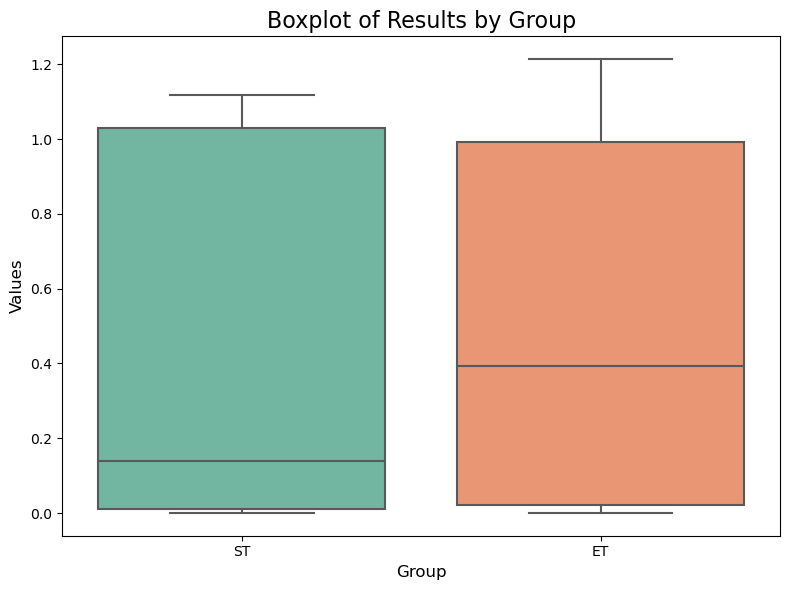

In [33]:
# Assuming your DataFrame is stored as 'df'
df = dev_lastANDtest

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['dev_percent'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_dev = df.groupby('Group')['dev_percent'].apply(find_outliers)

# Print outliers
print(outliers_dev)

# Optional: visualize outliers in a boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Group", y='dev_percent', palette="Set2")
plt.title('Boxplot of Results by Group', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.tight_layout()
plt.show()

In [34]:
from scipy.stats import shapiro

# Test normality for each measure
print("Shapiro-Wilk test for 'last':", shapiro(dev_lastANDtest['last']))
print("Shapiro-Wilk test for 'dev':", shapiro(dev_lastANDtest['dev_percent']))


Shapiro-Wilk test for 'last': ShapiroResult(statistic=0.8490869402885437, pvalue=0.00018135255959350616)
Shapiro-Wilk test for 'dev': ShapiroResult(statistic=0.756287157535553, pvalue=2.4615876554889837e-06)


In [35]:
dev_lastANDtest = dev_lastANDtest.reset_index()

In [159]:

# Convert from wide to long format
dev_lastANDtest_long = dev_lastANDtest.melt(id_vars=["Group", "SubGroup", "subId"], 
                  value_vars=["last", "dev"], 
                  var_name="Session", 
                  value_name="CorrectResponses")

In [160]:
dev_lastANDtest_long = dev_lastANDtest_long.dropna()

In [161]:
dev_lastANDtest_long.to_csv('dev_lastANDtest_long4.csv')

### Create plot for DEV results

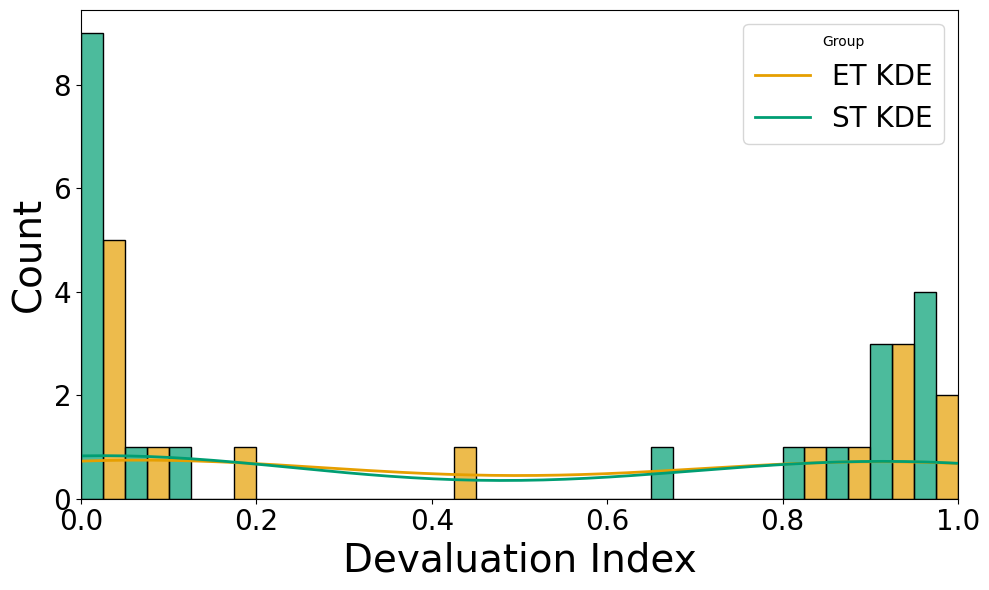

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = dev_lastANDtest

# Define the palette
palette = {"ET": "#E69F00", "ST": "#009E73"}

# Set figure size
plt.figure(figsize=(10, 6))

# Define bins (same for both groups)
num_bins = 20  # Adjust as needed
bin_min = df["dev"].min()
bin_max = df["dev"].max()
bins = np.linspace(bin_min, bin_max, num_bins + 1)  # Ensure equal bin widths

# Create histogram with dodged bars (bars next to each other)
sns.histplot(
    data=df,
    x="dev",
    hue="Group",
    bins=bins,
    multiple="dodge",  # Ensures bars are next to each other
    palette=palette,
    alpha=0.7,  # Transparency to make it clearer
    legend=True
)

# Overlay KDE plots
for group, color in palette.items():
    sns.kdeplot(
        data=df[df["Group"] == group],
        x="dev",
        color=color,
        linewidth=2,
        label=f"{group} KDE"
    )

# Labels and title
plt.xlabel("Devaluation Index", fontsize=28)
plt.ylabel("Count", fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlim(0,1)
# Ensure the legend is visible
plt.legend(title="Group", fontsize=20)

# Save and show
plt.tight_layout()
plt.savefig("dev_test_histogram_kde_dodged_pilot4.png", dpi=300, bbox_inches="tight")
plt.show()


In [40]:
et_per = (etDevResults[0]/et_last_devResults[0]).dropna()
et_per = et_per.reset_index()
et_per["Group"] = "ET"
st_per = (stDevResults[0]/st_last_devResults[0]).dropna()
st_per = st_per.reset_index()
st_per["Group"] = "ST"

In [41]:
ET_Left = (dev13['dev'])/(last_dev13['last'])
ET_Left = ET_Left.reset_index()
ET_Left["Group"] = "ET_Left"
ST_Left = (dev11['dev']/last_dev11['last'])
ST_Left = ST_Left.reset_index()
ST_Left["Group"] = "ST_Left"
ET_Right = (dev14['dev']/last_dev14['last'])
ET_Right = ET_Right.reset_index()
ET_Right["Group"] = "ET_Right"
ST_Right = (dev12['dev']/last_dev12['last'])
ST_Right = ST_Right.reset_index()
ST_Right["Group"] = "ST_Right"
split = pd.DataFrame([0])
split['subId'] = [1]
split["SubGroup"] = 'Split'


In [42]:
ET_Right

,subId,0,Group
0,65eb0482d2c8fb647d0aefc7,1.010444,ET_Right
1,65eb0482d2c8fb647d0aefc8,0.944170,ET_Right
2,65eb0482d2c8fb647d0aefc9,0.000000,ET_Right
3,65eb0482d2c8fb647d0aefcb,0.034483,ET_Right
4,65eb0482d2c8fb647d0aefcc,0.393443,ET_Right
5,65eb0482d2c8fb647d0aefcf,0.176682,ET_Right
6,65eb0482d2c8fb647d0aefd0,1.000000,ET_Right
7,65eb0482d2c8fb647d0aefd2,0.985946,ET_Right
8,65ed6cddd2c8fb647d0af014,0.010476,ET_Right


In [43]:
# dev_per_hands = pd.concat([ST_Left, ST_Right,ET_Left, ET_Right])
# dev_per_hands = dev_per_hands.drop(columns=['index']).rename(columns={0:'Percent'})

In [44]:
split = split.rename(columns={0:'dev'})
split_ET_Left = pd.concat([dev13[['dev','SubGroup']], split])
split_ET_Right = pd.concat([dev14[['dev','SubGroup']], split])
split_ST_Left = pd.concat([dev11[['dev','SubGroup']], split])
split_ST_Right = pd.concat([dev12[['dev','SubGroup']], split])

/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_29950/2248275571.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

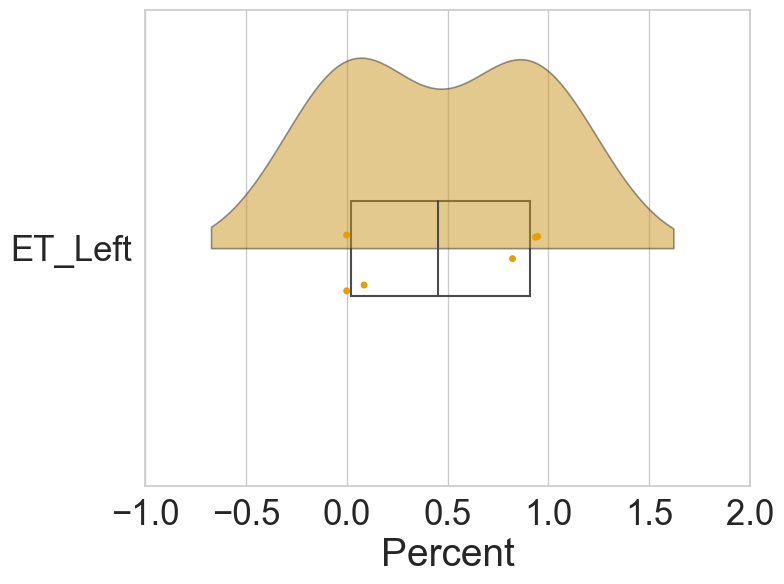

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ET_Left
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ET_Left": "#E69F00", "Split": "#009E73"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ET_Left"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
# ax.set_title("Pilot 4 - ET Left Devaluation", fontsize=14)
ax.set_xlabel("Percent", fontsize=28)
ax.set_ylabel("")
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.xticks()
ax.legend_.remove()
ax.set_xlim(-1, 2)
plt.tight_layout()
plt.savefig('ET - Left Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_29950/2365321775.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

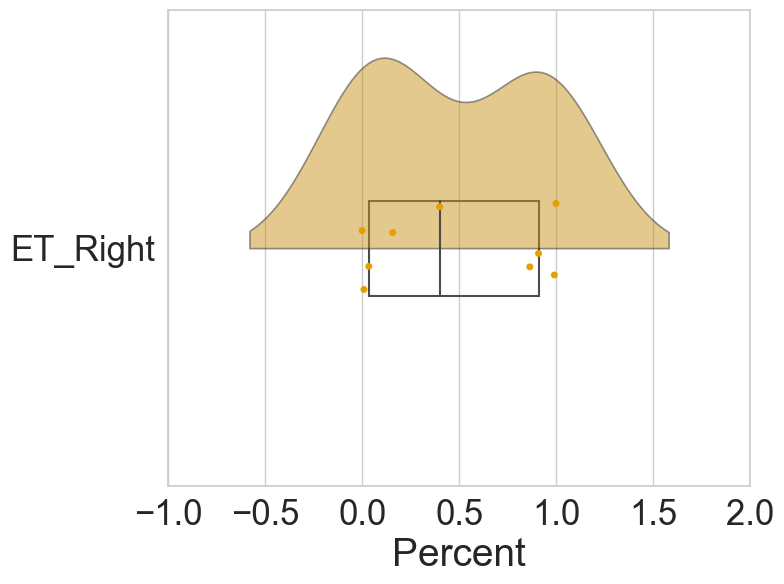

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ET_Right
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ET_Right": "#E69F00", "Split": "#009E73"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ET_Right"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
# ax.set_title("Pilot 4 - ET Right Devaluation", fontsize=14)
ax.set_xlabel("Percent", fontsize = 28)
ax.set_ylabel("")
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
ax.legend_.remove()
ax.set_xlim(-1, 2)
plt.tight_layout()
plt.savefig('ET - Right Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_29950/1822105548.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

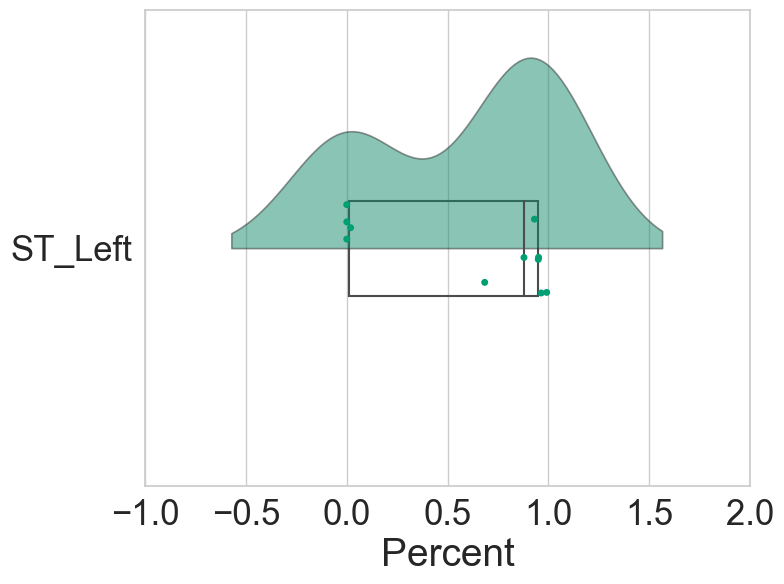

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ST_Left
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ST_Left": "#009E73", "Split": "#E69F00"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ST_Left"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
# ax.set_title("Pilot 4 - ST Left Devaluation", fontsize=14)
ax.set_xlabel("Percent", fontsize=28)
ax.set_ylabel("")
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
ax.legend_.remove()
ax.set_xlim(-1, 2)
plt.tight_layout()
plt.savefig('ST - Left Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_29950/637846177.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

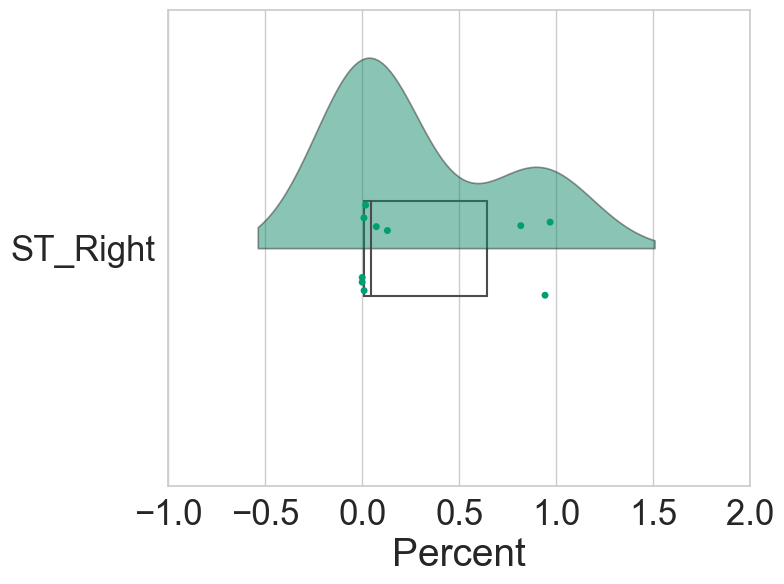

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ST_Right
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ST_Right": "#009E73", "Split": "#E69F00"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ST_Right"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
# ax.set_title("Pilot 4 - ST Right Devaluation", fontsize=14)
ax.set_xlabel("Percent", fontsize=28)
ax.set_ylabel("")
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
ax.legend_.remove()
ax.set_xlim(-1, 2)
plt.tight_layout()
plt.savefig('ST - Right Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


In [49]:
stDevResults.rename(columns={0: 'percent'}, inplace=True)
etDevResults.rename(columns={0: 'percent'}, inplace=True)

## Speeds & star tests:

In [50]:
st_count_Results = pd.DataFrame(pd.concat([results_additional[11], results_additional[12]], axis=0)).rename(columns={0:'howManyStars'})
et_count_Results = pd.DataFrame(pd.concat([results_additional[13], results_additional[14]], axis=0)).rename(columns={0:'howManyStars'})
choices11 = pd.DataFrame(results_main[11].allStars.groupby('subId').sum())
choices12 = pd.DataFrame(results_main[12].allStars.groupby('subId').sum())
choices13 = pd.DataFrame(results_main[13].allStars.groupby('subId').sum())
choices14 = pd.DataFrame(results_main[14].allStars.groupby('subId').sum())
st_choice_Results = pd.concat([choices11, choices12], axis=0)
et_choice_Results = pd.concat([choices13, choices14], axis=0)


In [51]:
st_count_Results['howManyStars'] = st_count_Results['howManyStars'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x)
et_count_Results['howManyStars'] = et_count_Results['howManyStars'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x)
et_count_Results['howManyStars'] = pd.to_numeric(et_count_Results['howManyStars'], errors='coerce').astype('Int64')
st_count_Results['howManyStars'] = pd.to_numeric(st_count_Results['howManyStars'], errors='coerce').astype('Int64')

In [52]:
st_accuracyCount_star = pd.DataFrame(1-(abs(st_choice_Results['allStars']-st_count_Results['howManyStars'])/st_choice_Results['allStars'])).astype('float64')
st_accuracyCount_star['Group'] = 'ST'
et_accuracyCount_star = pd.DataFrame(1-(abs(et_choice_Results['allStars']-et_count_Results['howManyStars'])/et_choice_Results['allStars'])).astype('float64')
et_accuracyCount_star['Group'] = 'ET'

In [53]:
accuracyCount_star = pd.concat([st_accuracyCount_star,et_accuracyCount_star]).rename(columns={'index':'subId'})

#### Outliers stars

Group  subId                   
ET     65e86454d2c8fb647d0aef74   1.000000
       65e86454d2c8fb647d0aef76   1.000000
       65e86454d2c8fb647d0aef79   0.703704
       65eb0482d2c8fb647d0aefcc   0.724138
       65eb0482d2c8fb647d0aefcf   0.851852
       65ed6cddd2c8fb647d0af014   1.000000
Name: 0, dtype: float64


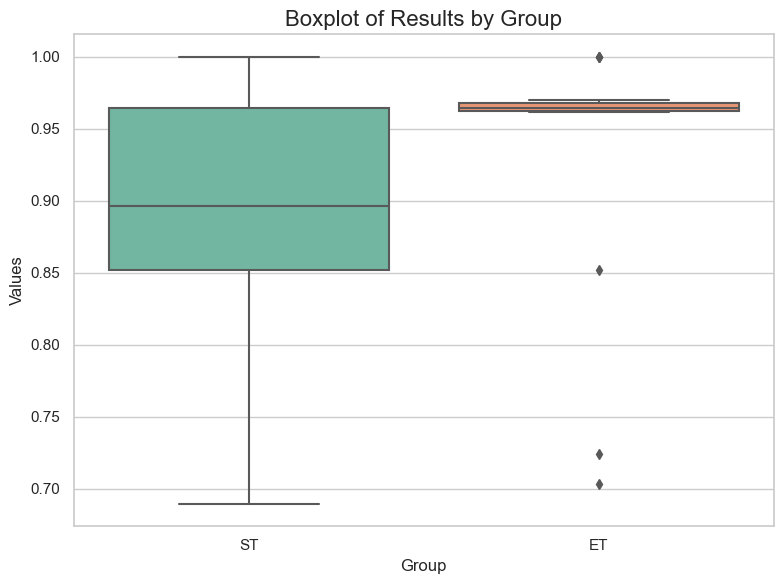

In [54]:
# Assuming your DataFrame is stored as 'df'
df = accuracyCount_star

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')[0].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_stars_count = df.groupby('Group')[0].apply(find_outliers)

# Print outliers
print(outliers_stars_count)

# Optional: visualize outliers in a boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Group", y=0, palette="Set2")
plt.title('Boxplot of Results by Group', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.tight_layout()
plt.show()


In [55]:
accuracyCount_star = accuracyCount_star.reset_index().rename(columns={'index':'subId'})

In [56]:
outliers_starts = pd.DataFrame(outliers_stars_count).reset_index().rename(columns={'level_1':'subId'})
outliersStars_subIds = outliers_starts['subId']

In [57]:
df_stars_cleaned = accuracyCount_star[~accuracyCount_star['subId'].isin(outliersStars_subIds)]

#### Stars stats and plot

In [58]:
df_stars_cleaned[df_stars_cleaned['Group']=='ET'].describe()

,0
count,9.000000
mean,0.964708
std,0.002236
min,0.961538
25%,0.964286
50%,0.964286
75%,0.965517
max,0.969697


In [59]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_stars_cleaned[df_stars_cleaned['Group'] == 'ST'][0]))
print("Shapiro-Wilk test for 'ET':", shapiro(df_stars_cleaned[df_stars_cleaned['Group'] == 'ET'][0]))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9263838529586792, pvalue=0.11648248881101608)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.862797200679779, pvalue=0.10282927751541138)


In [60]:
# Extract data for the two groups
group_ST = df_stars_cleaned[df_stars_cleaned['Group']=='ST'][0]
group_ET = df_stars_cleaned[df_stars_cleaned['Group']=='ET'][0]

# Perform independent t-test
statistic, p_value = ttest_ind(group_ST, group_ET)

# Compute Cohen's d
mean_ST, mean_ET = np.mean(group_ST), np.mean(group_ET)
std_ST, std_ET = np.std(group_ST, ddof=1), np.std(group_ET, ddof=1)  # Sample std deviation
n_ST, n_ET = len(group_ST), len(group_ET)

# Pooled standard deviation
s_pooled = np.sqrt(((n_ST - 1) * std_ST**2 + (n_ET - 1) * std_ET**2) / (n_ST + n_ET - 2))

# Compute Cohen’s d
cohens_d = (mean_ST - mean_ET) / s_pooled

# Print results
print(f"T-test: t = {statistic:.2f}, p-value = {p_value:.6f}")
print(f"Cohen's d = {cohens_d:.3f}")


T-test: t = -2.36, p-value = 0.025740
Cohen's d = -0.938


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_29950/3493107499.py:12: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


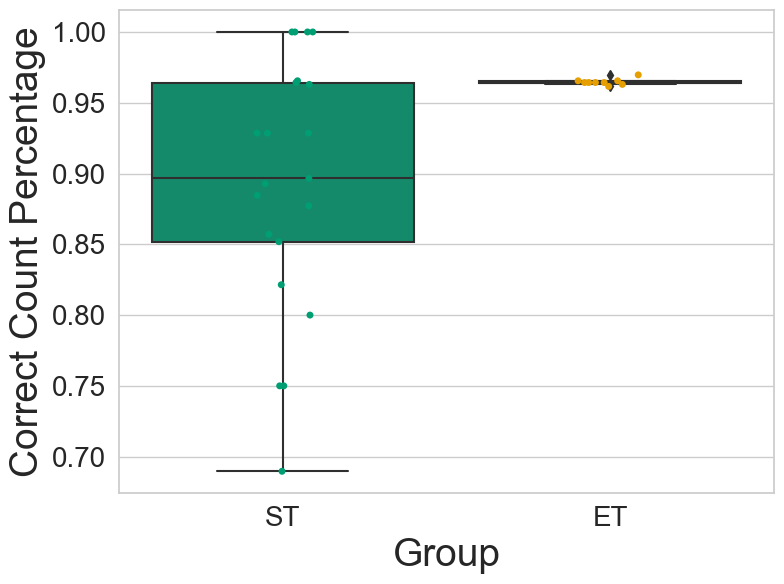

In [61]:

# Assuming your DataFrame is stored as 'df'
df = df_stars_cleaned  # Your DataFrame

# Create the plot
plt.figure(figsize=(8, 6))  # Set figure size

palette = {"ET": "#E69F00", "ST": "#009E73"}
# Create the boxplot
sns.boxplot(data=df, x="Group", y=0, palette=palette)  # Boxplot for the values

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x="Group", y=0, jitter=True, size=5, alpha=1, palette=palette
)  # Stripplot on top of the boxplot

# Title and labels
# plt.title('Automaticity test - Pilot 4', fontsize=16)
plt.xlabel('Group', fontsize=28)
plt.ylabel('Correct Count Percentage', fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# Show the plot
plt.tight_layout()
plt.savefig('Automaticity test.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)

plt.show()


#### Stars and Speeds presses

In [62]:
accuracy_press11 = pd.DataFrame([(results_main[11].correctFirstBluePressStar.groupby('subId').sum()+results_main[11].correctFirstRedPressStar.groupby('subId').sum())/(results_main[11].blueChoiceStar.groupby('subId').sum()+\
results_main[11].redChoiceStar.groupby('subId').sum()), (results_main[11].correctFirstBluePressSpeeds.groupby('subId').sum()+results_main[11].correctFirstRedPressSpeeds.groupby('subId').sum())/(results_main[11].blueChoiceSpeeds.groupby('subId').sum()+\
results_main[11].redChoiceSpeeds.groupby('subId').sum())]).T.rename(columns={0: 'Stars', 1: 'Speeds'})
accuracy_press12 = pd.DataFrame([(results_main[12].correctFirstBluePressStar.groupby('subId').sum()+results_main[12].correctFirstRedPressStar.groupby('subId').sum())/(results_main[12].blueChoiceStar.groupby('subId').sum()+\
results_main[12].redChoiceStar.groupby('subId').sum()), (results_main[12].correctFirstBluePressSpeeds.groupby('subId').sum()+results_main[12].correctFirstRedPressSpeeds.groupby('subId').sum())/(results_main[12].blueChoiceSpeeds.groupby('subId').sum()+\
results_main[12].redChoiceSpeeds.groupby('subId').sum())]).T.rename(columns={0: 'Stars', 1: 'Speeds'})
accuracy_press13 = pd.DataFrame([(results_main[13].correctFirstBluePressStar.groupby('subId').sum()+results_main[13].correctFirstRedPressStar.groupby('subId').sum())/(results_main[13].blueChoiceStar.groupby('subId').sum()+\
results_main[13].redChoiceStar.groupby('subId').sum()), (results_main[13].correctFirstBluePressSpeeds.groupby('subId').sum()+results_main[13].correctFirstRedPressSpeeds.groupby('subId').sum())/(results_main[13].blueChoiceSpeeds.groupby('subId').sum()+\
results_main[13].redChoiceSpeeds.groupby('subId').sum())]).T.rename(columns={0: 'Stars', 1: 'Speeds'})
accuracy_press14 = pd.DataFrame([(results_main[14].correctFirstBluePressStar.groupby('subId').sum()+results_main[14].correctFirstRedPressStar.groupby('subId').sum())/(results_main[14].blueChoiceStar.groupby('subId').sum()+\
results_main[14].redChoiceStar.groupby('subId').sum()), (results_main[14].correctFirstBluePressSpeeds.groupby('subId').sum()+results_main[14].correctFirstRedPressSpeeds.groupby('subId').sum())/(results_main[14].blueChoiceSpeeds.groupby('subId').sum()+\
results_main[14].redChoiceSpeeds.groupby('subId').sum())]).T.rename(columns={0: 'Stars', 1: 'Speeds'})
st_accuracyPress_Results = pd.concat([accuracy_press11, accuracy_press12], axis=0)
st_accuracyPress_Results['Group'] = 'ST'
et_accuracyPress_Results = pd.concat([accuracy_press13, accuracy_press14], axis=0)
et_accuracyPress_Results['Group'] = 'ET'

In [63]:
accuracyPress_Results = pd.concat([st_accuracyPress_Results, et_accuracyPress_Results])


In [64]:
accuracyPress_Results.describe()

,Stars,Speeds
count,36.000000,36.000000
mean,0.889578,0.812369
std,0.091784,0.127083
min,0.609756,0.569620
25%,0.865854,0.731013
50%,0.926829,0.837662
75%,0.942073,0.922078
max,1.000000,0.974684


In [65]:
accuracyPress_Results[accuracyPress_Results['Group']=='ST'].describe()

,Stars,Speeds
count,21.000000,21.000000
mean,0.879424,0.807269
std,0.096338,0.108678
min,0.609756,0.582278
25%,0.865854,0.734177
50%,0.914634,0.815789
75%,0.928571,0.898734
max,0.987805,0.974684


In [66]:
accuracyPress_Results_stars = accuracyPress_Results[['Stars','Group']].reset_index()
accuracyPress_Results_stars = accuracyPress_Results_stars[~accuracyPress_Results_stars['subId'].isin(outliersStars_subIds)].set_index('subId')
accuracyPress_Results_Speeds = accuracyPress_Results[['Speeds','Group']]

#### Speeds presses

In [67]:
accuracyPress_Results_Speeds[accuracyPress_Results_Speeds['Group']=='ET'].describe()

,Speeds
count,15.000000
mean,0.819510
std,0.152999
min,0.569620
25%,0.696203
50%,0.921053
75%,0.936303
max,0.974026


In [68]:
# Assuming your DataFrame is stored as 'df'
df = accuracyPress_Results_Speeds

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Speeds'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_speeds = df.groupby('Group')['Speeds'].apply(find_outliers)

# Print outliers
print(outliers_speeds)


# plt.figure(figsize=(8, 6))
# sns.boxplot(data=df, x="Group", y='Stars', palette="Set2")
# plt.title('Boxplot of Results by Group', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Values', fontsize=12)
# plt.tight_layout()
# plt.show()


Series([], Name: Speeds, dtype: float64)


In [69]:
outliers_Speeds_press = pd.DataFrame(outliers_speeds).reset_index()
outliersSpeedsPress_subIds = outliers_Speeds_press['subId']
accuracyPress_Results_Speeds = accuracyPress_Results_Speeds.reset_index()

In [70]:
df_SpeedsPress_cleaned = accuracyPress_Results_Speeds[~accuracyPress_Results_Speeds['subId'].isin(outliersSpeedsPress_subIds)]

In [71]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_SpeedsPress_cleaned[df_SpeedsPress_cleaned['Group']=='ST']['Speeds']))
print("Shapiro-Wilk test for 'ET':", shapiro(df_SpeedsPress_cleaned[df_SpeedsPress_cleaned['Group']=='ET']['Speeds']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9587655663490295, pvalue=0.4916153848171234)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.8335980176925659, pvalue=0.0102598387748003)


In [72]:
from scipy.stats import mannwhitneyu, norm

# Extract data for the two groups
group_ST = df_SpeedsPress_cleaned[df_SpeedsPress_cleaned['Group']=='ST']['Speeds']
group_ET = df_SpeedsPress_cleaned[df_SpeedsPress_cleaned['Group']=='ET']['Speeds']

# Perform Mann-Whitney U test
U_stat, p_value = mannwhitneyu(group_ST, group_ET)

# Compute effect size (r) using the Z-score method
n_ST, n_ET = len(group_ST), len(group_ET)
z_score = norm.ppf(1 - p_value / 2)  # Convert p-value to Z-score
effect_size_r = z_score / np.sqrt(n_ST + n_ET)  # r = Z / sqrt(N)

# Print results
print(f"Mann-Whitney U test: U = {U_stat:.2f}, p-value = {p_value:.6f}")
print(f"Effect size (r) = {effect_size_r:.3f}")

Mann-Whitney U test: U = 134.00, p-value = 0.460306
Effect size (r) = 0.123


In [73]:
df_SpeedsPress_cleaned[df_SpeedsPress_cleaned['Group']=='ET'].describe()

,Speeds
count,15.000000
mean,0.819510
std,0.152999
min,0.569620
25%,0.696203
50%,0.921053
75%,0.936303
max,0.974026


In [74]:
df_SpeedsPress_cleaned.describe()

,Speeds
count,36.000000
mean,0.812369
std,0.127083
min,0.569620
25%,0.731013
50%,0.837662
75%,0.922078
max,0.974684


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_29950/1720579199.py:12: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


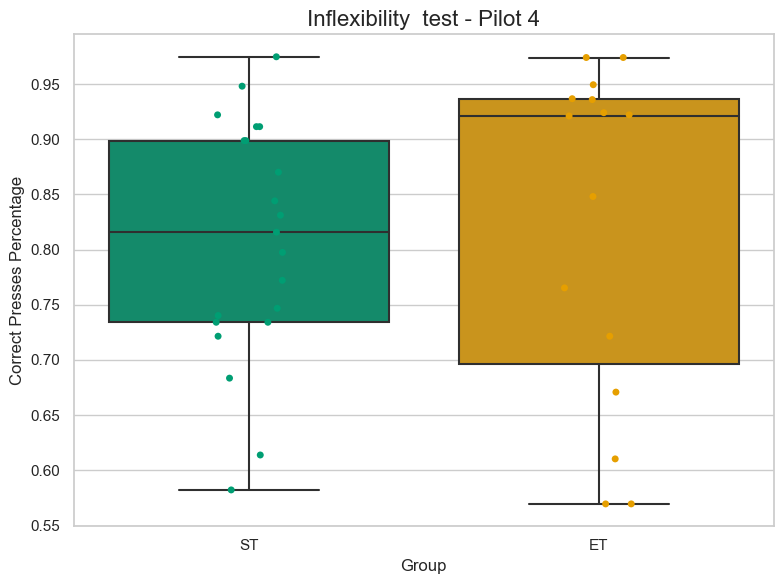

In [75]:

# Assuming your DataFrame is stored as 'df'
df = df_SpeedsPress_cleaned  # Your DataFrame

# Create the plot
plt.figure(figsize=(8, 6))  # Set figure size

palette = {"ET": "#E69F00", "ST": "#009E73"}
# Create the boxplot
sns.boxplot(data=df, x="Group", y='Speeds', palette=palette)  # Boxplot for the values

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x="Group", y='Speeds', jitter=True, size=5, alpha=1, palette=palette
)  # Stripplot on top of the boxplot

# Title and labels
plt.title('Inflexibility  test - Pilot 4', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Correct Presses Percentage', fontsize=12)

# Show the plot
plt.tight_layout()
plt.savefig('Inflexibility test.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)

plt.show()


#### Stars presses

In [76]:
# Assuming your DataFrame is stored as 'df'
df = accuracyPress_Results_stars

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Stars'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_stars = df.groupby('Group')['Stars'].apply(find_outliers)

# Print outliers
print(outliers_stars)


# plt.figure(figsize=(8, 6))
# sns.boxplot(data=df, x="Group", y='Stars', palette="Set2")
# plt.title('Boxplot of Results by Group', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Values', fontsize=12)
# plt.tight_layout()
# plt.show()


Group  subId                   
ET     65eb0482d2c8fb647d0aefd2   0.719512
ST     65f2b24fd2c8fb647d0af0dc   0.761905
       65f2b24fd2c8fb647d0af0dd   0.609756
       65f2b26ed2c8fb647d0af0ef   0.670732
Name: Stars, dtype: float64


In [77]:
outliers_stars = pd.DataFrame(outliers_stars).reset_index()

In [78]:
outliers_Stars_press = pd.DataFrame(outliers_stars).reset_index()
outliersStarsPress_subIds = outliers_stars['subId']
accuracyPress_Results_stars = accuracyPress_Results_stars.reset_index()

In [79]:
df_StarsPress_cleaned = accuracyPress_Results_stars[~accuracyPress_Results_stars['subId'].isin(outliersStarsPress_subIds)]

In [80]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ST']['Stars']))
print("Shapiro-Wilk test for 'ET':", shapiro(df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ET']['Stars']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9550313353538513, pvalue=0.5092576742172241)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.859869658946991, pvalue=0.11971630901098251)


In [81]:
group_ST = df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ST']['Stars']
group_ET = df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ET']['Stars']

# Perform independent t-test
statistic, p_value = ttest_ind(group_ST, group_ET)

# Compute Cohen's d
mean_ST, mean_ET = np.mean(group_ST), np.mean(group_ET)
std_ST, std_ET = np.std(group_ST, ddof=1), np.std(group_ET, ddof=1)  # Sample std deviation
n_ST, n_ET = len(group_ST), len(group_ET)

# Pooled standard deviation
s_pooled = np.sqrt(((n_ST - 1) * std_ST**2 + (n_ET - 1) * std_ET**2) / (n_ST + n_ET - 2))

# Compute Cohen’s d
cohens_d = (mean_ST - mean_ET) / s_pooled

# Print results
print(f"T-test: t = {statistic:.2f}, p-value = {p_value:.6f}")
print(f"Cohen's d = {cohens_d:.3f}")



T-test: t = -0.28, p-value = 0.778462
Cohen's d = -0.121


In [82]:
statistic, p_value = ttest_ind(df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ST']['Stars'], df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ET']['Stars'])
print(statistic, p_value)

-0.28450776517780163 0.7784617207616468


In [83]:
df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ET'].describe()

,Stars
count,8.000000
mean,0.918808
std,0.064295
min,0.785714
25%,0.912892
50%,0.933798
75%,0.954378
max,0.987654


In [84]:
df_stars_cleaned = df_stars_cleaned.rename(columns={0:'Count'})#.set_index('subId').drop(columns=['Group'])
accuracyPress_Results_stars = accuracyPress_Results_stars.rename(columns={'Stars':'Presses'})#.set_index('subId')
stars4 = pd.concat([df_stars_cleaned, accuracyPress_Results_stars], axis=1).dropna()
stars4['Pilot'] = 4

In [85]:
stars4#.to_csv('stars4.csv')

,subId,Count,Group,subId,Presses,Group,Pilot
0,65f2b24fd2c8fb647d0af0dc,0.800000,ST,65f2b24fd2c8fb647d0af0dc,0.761905,ST,4
1,65f2b24fd2c8fb647d0af0dd,0.928571,ST,65f2b24fd2c8fb647d0af0dd,0.609756,ST,4
2,65f2b24fd2c8fb647d0af0de,0.750000,ST,65f2b24fd2c8fb647d0af0de,0.926829,ST,4
3,65f2b24fd2c8fb647d0af0df,0.964286,ST,65f2b24fd2c8fb647d0af0df,0.964286,ST,4
4,65f2b24fd2c8fb647d0af0e0,0.896552,ST,65f2b24fd2c8fb647d0af0e0,0.926829,ST,4
5,65f2b24fd2c8fb647d0af0e1,0.689655,ST,65f2b24fd2c8fb647d0af0e1,0.926829,ST,4
6,65f2b24fd2c8fb647d0af0e3,0.851852,ST,65f2b24fd2c8fb647d0af0e3,0.913580,ST,4
7,65f2b24fd2c8fb647d0af0e4,0.965517,ST,65f2b24fd2c8fb647d0af0e4,0.928571,ST,4
8,65f2b24fd2c8fb647d0af0e5,1.000000,ST,65f2b24fd2c8fb647d0af0e5,0.892857,ST,4
9,65f2b24fd2c8fb647d0af0e6,0.857143,ST,65f2b24fd2c8fb647d0af0e6,0.963415,ST,4


## RT

### RT for stars test

In [162]:
outliersStars = pd.concat([outliersStars_subIds,outliers_stars])

In [163]:
RTs = {}

for i in range(11, 15):
    RT = {}
    RT['Blue'] = {}
    RT['Red'] = {}

    # Filter relevant data
    dfs[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]
    dfs[i] = dfs[i][~dfs[i]['subId'].isin(outliersStars)]

    # Iterate over rows for BLUE choices
    for row in dfs[i][['subId', 'correctFirstBluePressStar', 'blueChoiceStar']].dropna().iterrows():
        RT_blue_row = {}
        subId = row[1].subId  # Extract subId

        for ind, correctFirstBluePressStar in enumerate(row[1].correctFirstBluePressStar):
            valid_choices = [x for x in row[1].blueChoiceStar if x < correctFirstBluePressStar]
            RT_blue_row[ind] = correctFirstBluePressStar - valid_choices[-1] if valid_choices else None  # Handle empty list

        if len(RT_blue_row) > 0:
            RT['Blue'][row[0]] = {'RTs': list(RT_blue_row.values()), 'subId': subId}  # Store subId

    # Iterate over rows for RED choices
    for row in dfs[i][['subId', 'correctFirstRedPressStar', 'redChoiceStar']].dropna().iterrows():
        RT_red_row = {}
        subId = row[1].subId  # Extract subId

        for ind, correctFirstRedPressStar in enumerate(row[1].correctFirstRedPressStar):
            valid_choices = [x for x in row[1].redChoiceStar if x < correctFirstRedPressStar]
            RT_red_row[ind] = correctFirstRedPressStar - valid_choices[-1] if valid_choices else None  # Handle empty list

        if len(RT_red_row) > 0:
            RT['Red'][row[0]] = {'RTs': list(RT_red_row.values()), 'subId': subId}  # Store subId

    # Convert to DataFrame
    RTs[i] = pd.DataFrame.from_dict({(key, subkey): values 
                                     for key, subdict in RT.items() 
                                     for subkey, values in subdict.items()}, 
                                     orient='index')

    # Reset index to make 'Color' and 'RowIndex' columns
    RTs[i].reset_index(inplace=True)
    RTs[i].rename(columns={'level_0': 'Color', 'level_1': 'RowIndex'}, inplace=True)

    # Ensure 'subId' is set as an index or a column
    RTs[i] = RTs[i].set_index('subId')

    # Expand dictionary values into separate columns
    RTs[i] = pd.concat([RTs[i], RTs[i].apply(lambda row: pd.Series(row[0]), axis=1)], axis=1)

    # Drop unnecessary nested dictionary column
    RTs[i].drop(columns=[0], inplace=True, errors='ignore')



In [164]:
def to_list(a):
    if isinstance(a, float):
        return [a]
    return a

In [165]:
mean_RTs = {}

for grp, RT in RTs.items():
    # Compute mean RTs while keeping 'subId'
    mean_df = RT.groupby(["subId", "Color"])["RTs"].apply(lambda x: 
        pd.Series([item for sublist in x.dropna() for item in to_list(sublist)]).mean()
    ).unstack()  # Convert 'Color' categories into separate columns

    # Store the result
    mean_RTs[grp] = mean_df.reset_index()  # Ensure 'subId' is a column


In [166]:
BandRST = pd.concat([mean_RTs[11], mean_RTs[12]]).reset_index()
BandRST["Group"]="ST"
BandRET = pd.concat([mean_RTs[13], mean_RTs[14]]).reset_index()
BandRET["Group"]="ET"
BandR = pd.concat([BandRST,BandRET])
BandR = BandR.drop(columns = "index")
BandR['Hand_mean'] = BandR[['Blue', 'Red']].mean(axis=1)

In [167]:
BandR = BandR.reset_index().melt(id_vars=['subId', 'Group'], 
                                  value_vars=['Hand_mean'], 
                                  var_name='Color', 
                                  value_name='MeanRT')


In [170]:
# Assuming your DataFrame is stored as 'df'
df = BandR.set_index('subId')

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['MeanRT'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_stars = df.groupby('Group')['MeanRT'].apply(find_outliers)

# Print outliers
print(outliers_RT_stars)

Group  subId                   
ST     65f2b24fd2c8fb647d0af0e5   532.018651
       65f2b26ed2c8fb647d0af0f4   532.280081
Name: MeanRT, dtype: float64


In [172]:
outliers_RT_Stars = pd.DataFrame(outliers_RT_stars).reset_index()
outliers_RT_Stars_subIds = outliers_RT_Stars['subId']

In [173]:
outliers_RT_Stars

,Group,subId,MeanRT
0,ST,65f2b24fd2c8fb647d0af0e5,532.018651
1,ST,65f2b26ed2c8fb647d0af0f4,532.280081


In [174]:
BandR = BandR.reset_index()

In [175]:
df_RT_Stars_cleaned = BandR[~BandR['index'].isin(outliers_RT_Stars_subIds)]

In [176]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(BandR[BandR['Group']=='ST']['MeanRT'].dropna()))
print("Shapiro-Wilk test for 'ET':", shapiro(BandR[BandR['Group']=='ET']['MeanRT'].dropna()))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9586447477340698, pvalue=0.48925626277923584)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9651257991790771, pvalue=0.7804959416389465)


In [98]:
# Extract data for the two groups
group_ST = BandR[BandR['Group']=='ST']['MeanRT'].dropna()
group_ET = BandR[BandR['Group']=='ET']['MeanRT'].dropna()
# Perform independent t-test
statistic, p_value = ttest_ind(group_ST, group_ET)

# Compute Cohen's d
mean_ST, mean_ET = np.mean(group_ST), np.mean(group_ET)
std_ST, std_ET = np.std(group_ST, ddof=1), np.std(group_ET, ddof=1)  # Sample std deviation
n_ST, n_ET = len(group_ST), len(group_ET)

# Pooled standard deviation
s_pooled = np.sqrt(((n_ST - 1) * std_ST**2 + (n_ET - 1) * std_ET**2) / (n_ST + n_ET - 2))

# Compute Cohen’s d
cohens_d = (mean_ST - mean_ET) / s_pooled

# Welch-Satterthwaite degrees of freedom
df = (std_ST**2/n_ST + std_ET**2/n_ET)**2 / (
    (std_ST**2/n_ST)**2/(n_ST-1) + (std_ET**2/n_ET)**2/(n_ET-1)
)

# Print results
print(f"T-test: t{df:.2f} = {statistic:.2f}, p-value = {p_value:.6f}")
print(f"Cohen's d = {cohens_d:.3f}")


T-test: t28.69 = 0.25, p-value = 0.804817
Cohen's d = 0.084


In [99]:
df_RT_Stars_cleaned[df_RT_Stars_cleaned['Group']=='ET']['MeanRT'].describe()

count    30.000000
mean    630.590406
std      60.215907
min     535.704545
25%     586.819184
50%     622.721491
75%     675.313393
max     768.617647
Name: MeanRT, dtype: float64

In [100]:
# cohend(BandRST[0].dropna(), BandRET[0].dropna())

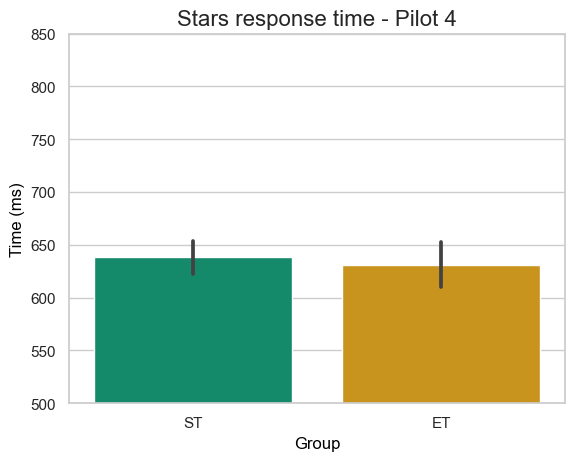

In [101]:

# Define custom colors
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_Stars_cleaned, x="Group", y="MeanRT", palette=custom_palette)

# Set axis limits
plt.ylim(500, 850)

# Customize axis labels
ax.set_xlabel("Group", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

plt.title('Stars response time - Pilot 4', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Correct Presses Percentage', fontsize=12)
# Save the figure
plt.savefig("response_time_stars.png")

# Show the plot
plt.show()


In [102]:
df_RT_Stars_cleaned['Pilot'] = 4
df_RT_Stars_cleaned.to_csv('df_RT_Stars_cleaned4.csv')

/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_29950/4050343986.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_RT_Stars_cleaned['Pilot'] = 4


### RT training

In [270]:
# Create a function to filter elements in the list that are greater than 180,000 milliseconds
def filter_list_RTs(lst):
    if len([item for item in lst if isinstance(item, int) and item > 180000])==0:
           return np.nan
    return [item for item in lst if isinstance(item, int) and item > 180000]

In [271]:
dfs_for_RT_blue = {}
dfs_for_RT_red = {}
dfs_for_RT = {}

for i in range (13, 15):
    dfs_for_RT_blue[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]\
    .set_index(['subId',dfs[i][dfs[i].subId.isin(relevent_subIds[i])].createdAt.str[:10]])[['correctFirstBluePress', 'blueChoice']].dropna().reset_index()
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i][dfs_for_RT_blue[i]['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_blue[i]['correctFirstBluePress'] = dfs_for_RT_blue[i]['correctFirstBluePress'].apply(filter_list_RTs)
    dfs_for_RT_blue[i]['blueChoice'] = dfs_for_RT_blue[i]['blueChoice'].apply(filter_list_RTs)
    dfs_for_RT_blue[i].sort_values(by='createdAt', ascending=True, inplace=True)
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i].groupby('subId').apply(fix_subId)
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i].drop(columns=['subId'])

    dfs_for_RT_red[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]\
    .set_index(['subId',dfs[i][dfs[i].subId.isin(relevent_subIds[i])].createdAt.str[:10]])[['correctFirstRedPress', 'redChoice']].dropna().reset_index()
    dfs_for_RT_red[i] = dfs_for_RT_red[i][dfs_for_RT_red[i]['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_red[i]['correctFirstRedPress'] = dfs_for_RT_red[i]['correctFirstRedPress'].apply(filter_list_RTs)
    dfs_for_RT_red[i]['redChoice'] = dfs_for_RT_red[i]['redChoice'].apply(filter_list_RTs)
    dfs_for_RT_red[i].sort_values(by='createdAt', ascending=True, inplace=True)
    dfs_for_RT_red[i] = dfs_for_RT_red[i].groupby('subId').apply(fix_subId)
    dfs_for_RT_red[i] = dfs_for_RT_red[i].drop(columns=['subId','createdAt'])

    
for i in range (11, 13):    
    dfs_for_RT_blue[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]\
    .set_index(['subId',dfs[i][dfs[i].subId.isin(relevent_subIds[i])].createdAt.str[:10]])[['correctFirstBluePress', 'blueChoice']].dropna().reset_index()
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i][dfs_for_RT_blue[i]['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_blue[i]['correctFirstBluePress'] = dfs_for_RT_blue[i]['correctFirstBluePress'].apply(filter_list_RTs)
    dfs_for_RT_blue[i]['blueChoice'] = dfs_for_RT_blue[i]['blueChoice'].apply(filter_list_RTs)
    dfs_for_RT_blue[i].sort_values(by=['subId', 'createdAt'])
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i].groupby('subId', as_index=True).first()
    
    dfs_for_RT_red[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]\
    .set_index(['subId',dfs[i][dfs[i].subId.isin(relevent_subIds[i])].createdAt.str[:10]])[['correctFirstRedPress', 'redChoice']].dropna().reset_index()
    dfs_for_RT_red[i] = dfs_for_RT_red[i][dfs_for_RT_red[i]['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_red[i]['correctFirstRedPress'] = dfs_for_RT_red[i]['correctFirstRedPress'].apply(filter_list_RTs)
    dfs_for_RT_red[i]['redChoice'] = dfs_for_RT_red[i]['redChoice'].apply(filter_list_RTs)
    dfs_for_RT_red[i] = dfs_for_RT_red[i].groupby('subId', as_index=True).first()
    dfs_for_RT_red[i] = dfs_for_RT_red[i].drop(columns=['createdAt'])

for i in range (11, 15):    
    dfs_for_RT[i] = pd.concat([dfs_for_RT_blue[i], dfs_for_RT_red[i]], axis=1).reset_index().rename(columns={'index': 'subId'})

In [272]:
for i in range(11, 15):
# Remove the first element from each list in the 'correctFirstBluePress' column for all rows
    dfs_for_RT[i]['correctFirstBluePress'] = dfs_for_RT[i]['correctFirstBluePress'].apply(
        lambda x: x[1:] if isinstance(x, list) and len(x) > 0 else x
    )
    dfs_for_RT[i]['correctFirstRedPress'] = dfs_for_RT[i]['correctFirstRedPress'].apply(
        lambda x: x[1:] if isinstance(x, list) and len(x) > 0 else x
    )
    # dfs_for_RT[14]['correctFirstRedPress'] = dfs_for_RT[14]['correctFirstRedPress'].apply(
    #     lambda x: x[1:] if isinstance(x, list) and len(x) > 0 else x
    # )

In [273]:
RTs_general = {}
Ts_general = {}
for i in range(11, 15):
    RT = {}
    RT['Blue'] = {}
    RT['Red'] = {}
    RT_df = dfs_for_RT[i]
    for row in RT_df[['subId', 'createdAt', 'correctFirstBluePress', 'blueChoice']].dropna().iterrows():
        RT_blue_row = {}
        subId = row[1].subId
        createdAt = row[1].createdAt
        
        for ind, correctFirstBluePress in enumerate(sorted(row[1].correctFirstBluePress)):
            row[1].blueChoice = sorted(row[1].blueChoice) 
            RT_blue_row[ind] = correctFirstBluePress - [x for x in row[1].blueChoice if x < correctFirstBluePress][-1]
        
        if len(RT_blue_row) > 0:
            RT['Blue'][row[0]] = {'RTs': list(RT_blue_row.values()), 'subId': subId, 'createdAt': createdAt}

    for row in RT_df[['subId', 'createdAt', 'correctFirstRedPress', 'redChoice']].dropna().iterrows():
        RT_red_row = {}
        subId = row[1].subId
        createdAt = row[1].createdAt

        for ind, correctFirstRedPress in enumerate(sorted(row[1].correctFirstRedPress)):
            RT_red_row[ind] = correctFirstRedPress - [x for x in row[1].redChoice if x < correctFirstRedPress][-1]
        
        if len(RT_red_row) > 0:
            RT['Red'][row[0]] = {'RTs': list(RT_red_row.values()), 'subId': subId, 'createdAt': createdAt}

        # Convert nested dictionary to DataFrame
        RTs_general[i] = pd.DataFrame.from_dict({(key, subkey): values 
                                                 for key, subdict in RT.items() 
                                                 for subkey, values in subdict.items()}, 
                                                 orient='index')

        # Reset index so 'Color' and 'RowIndex' become columns
        RTs_general[i].reset_index(inplace=True)
        RTs_general[i].rename(columns={'level_0': 'Color', 'level_1': 'RowIndex'}, inplace=True)
        RTs_general[i] = RTs_general[i].set_index('subId')
        # Expand dictionary values (RTs, subId, createdAt) into separate columns
        RTs_general[i] = pd.concat([RTs_general[i], RTs_general[i].apply(lambda row: pd.Series(row[0]), axis=1)], axis=1)

        # Drop the original column that stored the dictionaries (it has been expanded)
        RTs_general[i].drop(columns=[0], inplace=True, errors='ignore')  # 'ignore' avoids errors if the column doesn't exist

In [275]:
df_reset = {}
df_means = {}

for i in range (11,15):
    # Reset index to ensure 'subId' and 'Color' are columns
    df_reset[i] = RTs_general[i].reset_index().dropna()

    # Compute the mean RTs for each combination of 'subId' and 'Color'
    df_means[i] = df_reset[i].groupby(['subId', 'Color'])['RTs'].apply(lambda x: np.mean(x.values[0]) if isinstance(x.values[0], list) else np.nan).unstack()

    # Rename columns for clarity
    df_means[i].columns = ['MeanRT_Blue', 'MeanRT_Red']
    df_means[i]['Mean_All'] = df_means[i][['MeanRT_Blue', 'MeanRT_Red']].mean(axis=1)
    if i in range (11,13):
        df_means[i]['Group'] = 'ST'
    else:
        df_means[i]['Group'] = 'ET'

In [276]:
df_means = pd.concat([df_means[11],df_means[12],df_means[13],df_means[14]])

In [277]:
df_means.head()

,MeanRT_Blue,MeanRT_Red,Mean_All,Group
subId,,,,
65f2b24fd2c8fb647d0af0dc,590.886364,598.355556,594.620960,ST
65f2b24fd2c8fb647d0af0dd,680.723404,778.704545,729.713975,ST
65f2b24fd2c8fb647d0af0de,603.886792,698.239130,651.062961,ST
65f2b24fd2c8fb647d0af0df,589.836364,550.954545,570.395455,ST
65f2b24fd2c8fb647d0af0e0,629.632653,649.296296,639.464475,ST


In [278]:
# Reset index to make 'subId' a column before melting
RT_means_training = df_means.reset_index().melt(id_vars=['subId', 'Group'], 
                                  value_vars=['Mean_All'], 
                                  var_name='Color', 
                                  value_name='MeanRT')


In [279]:
# Assuming your DataFrame is stored as 'df'
df = RT_means_training

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['MeanRT'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_training = df.groupby('Group')['MeanRT'].apply(find_outliers)

# Print outliers
print(outliers_RT_training)

Group   
ST     1   729.713975
Name: MeanRT, dtype: float64


In [280]:
outliers_RT_training

Group   
ST     1   729.713975
Name: MeanRT, dtype: float64

In [281]:
outliers_RT_training = pd.DataFrame(outliers_RT_training).reset_index()
outliers_RT_training_subIds = outliers_RT_training['level_1']
RT_means_training = RT_means_training.reset_index()

In [282]:
df_RT_training_cleaned = RT_means_training[~RT_means_training['index'].isin(outliers_RT_training_subIds)]

In [283]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(RT_means_training[RT_means_training['Group']=='ST']['MeanRT'].dropna()))
print("Shapiro-Wilk test for 'ET':", shapiro(RT_means_training[RT_means_training['Group']=='ET']['MeanRT'].dropna()))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9764280915260315, pvalue=0.8663999438285828)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.926408588886261, pvalue=0.2715396583080292)


In [284]:
df_RT_Stars_cleaned

,index,subId,Group,Color,MeanRT
0,0,65f2b24fd2c8fb647d0af0dc,ST,Hand_mean,616.421053
1,1,65f2b24fd2c8fb647d0af0dd,ST,Hand_mean,727.582102
2,2,65f2b24fd2c8fb647d0af0de,ST,Hand_mean,680.926357
3,3,65f2b24fd2c8fb647d0af0df,ST,Hand_mean,609.697980
4,4,65f2b24fd2c8fb647d0af0e0,ST,Hand_mean,624.566949
5,5,65f2b24fd2c8fb647d0af0e1,ST,Hand_mean,610.548432
6,6,65f2b24fd2c8fb647d0af0e3,ST,Hand_mean,720.539435
7,7,65f2b24fd2c8fb647d0af0e4,ST,Hand_mean,619.950240
8,8,65f2b24fd2c8fb647d0af0e5,ST,Hand_mean,532.018651
9,9,65f2b24fd2c8fb647d0af0e6,ST,Hand_mean,652.778896


In [286]:
df_RT_Stars_cleaned = df_RT_Stars_cleaned.rename(columns={'Response time':'MeanRT'})
df_RT_Stars_cleaned['step'] = 'Stars'
RT_means_training['step'] = 'Training'
#,RT_means_training['MeanRT']

In [288]:
rt_stars_training = pd.concat([df_RT_Stars_cleaned,RT_means_training])

In [289]:
RT_means_training['Pilot'] = 4
df_RT_Stars_cleaned['Pilot'] = 4
df_RT_Stars_cleaned.to_csv('df_RT_Stars_cleaned4.csv')

In [290]:
rt_stars_training

,index,subId,Group,Color,MeanRT,Pilot,step
0,0,65f2b24fd2c8fb647d0af0dc,ST,Hand_mean,616.421053,4,Stars
1,1,65f2b24fd2c8fb647d0af0dd,ST,Hand_mean,727.582102,4,Stars
2,2,65f2b24fd2c8fb647d0af0de,ST,Hand_mean,680.926357,4,Stars
3,3,65f2b24fd2c8fb647d0af0df,ST,Hand_mean,609.697980,4,Stars
4,4,65f2b24fd2c8fb647d0af0e0,ST,Hand_mean,624.566949,4,Stars
...,...,...,...,...,...,...,...
30,30,65eb0482d2c8fb647d0aefcc,ET,Mean_All,578.858503,4,Training
31,31,65eb0482d2c8fb647d0aefcf,ET,Mean_All,708.373222,4,Training
32,32,65eb0482d2c8fb647d0aefd0,ET,Mean_All,580.851871,4,Training
33,33,65eb0482d2c8fb647d0aefd2,ET,Mean_All,669.855056,4,Training


In [291]:
# rt_stars_training = rt_stars_training.drop(columns=['index','Pilot','subId','Color'])
rt_stars_training['Pilot'] = 4
rt_stars_training.to_csv('rt_stars_training4.csv')

### RT for speeds

In [223]:
RTs_Speeds = {}

for i in range(11, 15):
    RT = {'subId':{},'Blue': {}, 'Red': {}}
    dfs[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]
    dfs[i] = dfs[i][~dfs[i]['subId'].isin(outliersSpeedsPress_subIds)]
    for row in dfs[i][['subId','correctFirstBluePressSpeeds', 'blueChoiceSpeeds']].dropna().iterrows():
        # print(row[1])
        # print()
        RT_blue_row = {}
        subId = row[1].subId
        counter = 0
        for correctFirstBluePressSpeeds in row[1].correctFirstBluePressSpeeds:
            choices_before_press = [x for x in row[1].blueChoiceSpeeds if x<correctFirstBluePressSpeeds]
            # print(correctFirstRedPressSpeeds, choices_before_press)
            if len(choices_before_press)>0:
                RT_blue_row[counter] = correctFirstBluePressSpeeds - choices_before_press[-1]
                counter += 1 
        # break         
        if len(RT_blue_row)>0:
            RT['Blue'][row[0]] = list(RT_blue_row.values())
            RT['subId'][row[0]] = subId
            
    for row in dfs[i][['subId','correctFirstRedPressSpeeds', 'redChoiceSpeeds']].dropna().iterrows():
        RT_red_row = {}
        subId = row[1].subId
        counter = 0
        for correctFirstRedPressSpeeds in row[1].correctFirstRedPressSpeeds:
            choices_before_press = [x for x in row[1].redChoiceSpeeds if x<correctFirstRedPressSpeeds]
            if len(choices_before_press)>0:
                RT_red_row[counter] = correctFirstRedPressSpeeds - choices_before_press[-1]
                counter += 1 
        if len(RT_red_row)>0:
            RT['Red'][row[0]] = list(RT_red_row.values())
            RT['subId'][row[0]] = subId

    # Convert nested dictionary to DataFrame
    RTs_Speeds[i] = pd.DataFrame(RT)

# Reset index so 'Color' and 'RowIndex' become columns
RTs_Speeds[i].reset_index(inplace=True)
RTs_Speeds[i].rename(columns={'level_0': 'Color', 'level_1': 'RowIndex'}, inplace=True)
RTs_Speeds[i] = RTs_Speeds[i].set_index('subId')
# Expand dictionary values (RTs, subId, createdAt) into separate columns
RTs_Speeds[i] = pd.concat([RTs_Speeds[i], RTs_Speeds[i].apply(lambda row: pd.Series(row[0]), axis=1)], axis=1)

# Drop the original column that stored the dictionaries (it has been expanded)
RTs_Speeds[i].drop(columns=[0], inplace=True, errors='ignore')  # 'ignore' avoids errors if the column doesn't exist

In [224]:
def to_list(a):
    if isinstance(a, float):
        return [a]
    return a

In [225]:
df_means = {}

for i in range(11, 15):

    df = RTs_Speeds[i].copy()

    # Make sure subId is always a regular column
    if 'subId' not in df.columns:
        df = df.reset_index()

    # Remove old row-index column if it exists
    if 'index' in df.columns:
        df = df.drop(columns='index')

    df_means[i] = pd.DataFrame()

    df_means[i]['subId'] = df['subId'].values

    df_means[i]['MeanRT_Blue'] = df['Blue'].apply(
        lambda x: np.mean(x) if isinstance(x, list) else np.nan
    ).values

    df_means[i]['MeanRT_Red'] = df['Red'].apply(
        lambda x: np.mean(x) if isinstance(x, list) else np.nan
    ).values

    df_means[i]['Mean_All'] = df_means[i][['MeanRT_Blue', 'MeanRT_Red']].mean(axis=1)

    df_means[i]['Group'] = 'ST' if i in range(11, 13) else 'ET'
    df_means[i]['Run'] = i

df_Speeds_mean_all = pd.concat(df_means.values(), ignore_index=True)

In [226]:
BandR_Speeds = df_Speeds_mean_all[['subId','Group','Mean_All']]

In [227]:
BandR_Speeds = BandR_Speeds.rename(columns={'Mean_All':'Response time'})
BandR_Speeds.head()

,subId,Group,Response time
0,65f2b24fd2c8fb647d0af0e4,ST,560.574194
1,65f2b24fd2c8fb647d0af0e1,ST,608.968750
2,65f2b24fd2c8fb647d0af0e0,ST,587.496296
3,65f2b24fd2c8fb647d0af0e6,ST,557.592857
4,65f2b24fd2c8fb647d0af0de,ST,563.247475


In [228]:
BandR_speeds = BandR_Speeds.reset_index()

In [231]:
# Assuming your DataFrame is stored as 'df'
df = BandR_speeds.set_index('subId')

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Response time'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_speeds = df.groupby('Group')['Response time'].apply(find_outliers)

# Print outliers
print(outliers_RT_speeds)

Series([], Name: Response time, dtype: float64)


In [232]:
outliers_RT_speeds = pd.DataFrame(outliers_RT_speeds).reset_index()
outliers_RT_speeds_subIds = outliers_RT_speeds['subId']

In [233]:
df_RT_speeds_cleaned = BandR_speeds[~BandR_speeds['subId'].isin(outliers_RT_speeds_subIds)]

In [234]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_RT_speeds_cleaned[df_RT_speeds_cleaned['Group']=='ST']['Response time']))
print("Shapiro-Wilk test for 'ET':", shapiro(df_RT_speeds_cleaned[df_RT_speeds_cleaned['Group']=='ET']['Response time']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9793413281440735, pvalue=0.905394434928894)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.831607460975647, pvalue=0.0096360445022583)


In [235]:
# Extract data for the two groups
group_ST = df_RT_speeds_cleaned[df_RT_speeds_cleaned['Group']=='ST']['Response time'].dropna()
group_ET = df_RT_speeds_cleaned[df_RT_speeds_cleaned['Group']=='ET']['Response time'].dropna()

# Perform Mann-Whitney U test
U_stat, p_value = mannwhitneyu(group_ST, group_ET)

# Compute effect size (r) using the Z-score method
n_ST, n_ET = len(group_ST), len(group_ET)
z_score = norm.ppf(1 - p_value / 2)  # Convert p-value to Z-score
effect_size_r = z_score / np.sqrt(n_ST + n_ET)  # r = Z / sqrt(N)

# Print results
print(f"Mann-Whitney U test: U = {U_stat:.2f}, p-value = {p_value:.6f}")
print(f"Effect size (r) = {effect_size_r:.3f}")

Mann-Whitney U test: U = 184.00, p-value = 0.567128
Effect size (r) = 0.094


In [131]:
df_RT_speeds_cleaned[df_RT_speeds_cleaned['Group']=='ST'].describe()

,index,Response time
count,44.000000,43.000000
mean,21.500000,581.331521
std,12.845233,48.204114
min,0.000000,492.900000
25%,10.750000,547.718915
50%,21.500000,573.928571
75%,32.250000,621.964368
max,43.000000,710.952381


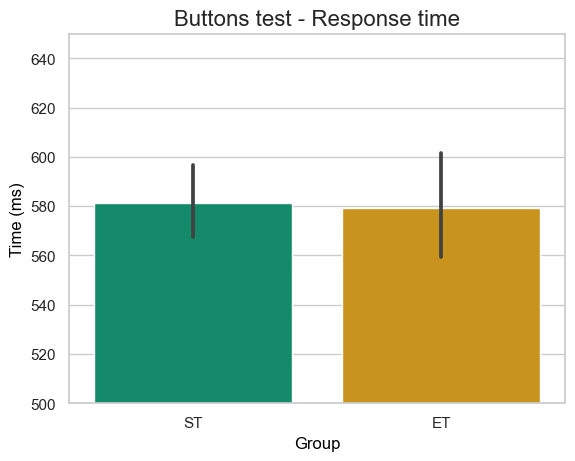

<Figure size 640x480 with 0 Axes>

In [132]:

# Define custom colors
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_speeds_cleaned, x="Group", y="Response time", palette=custom_palette)

# Set axis limits
plt.ylim(500, 650)

# Customize axis labels
ax.set_xlabel("Group", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

plt.title('Speeds test - Response time', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Correct Presses Percentage', fontsize=12)
# Save the figure
plt.savefig("response_time_stars.png")

# Show the plot
plt.show()

plt.savefig("response_time_Speeds.png")

### RT comperison:

In [133]:
RTs_general = {}
for i in range(11, 15):
    RTs = {'Blue': {}, 'Red': {}, 'subId': {}, 'createdAt': {}}  # Initialize RTs for each iteration
    dfs[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]
    for index, row in dfs[i][['subId', 'createdAt']].dropna().iterrows():
        subId = row['subId']
        createdAt = row['createdAt']
        RTs['subId'][index] = subId
        RTs['createdAt'][index] = int(createdAt[8:10])
        # RTs['createdAt'][index] = createdAt
        for index2, row2 in dfs[i][['correctFirstBluePress', 'blueChoice']].dropna().iterrows():
            RT = {'Blue': {}, 'Red': {}}  # Initialize RT for each row
            RT_blue_row = {}
            for ind, correctFirstBluePress in enumerate(row2['correctFirstBluePress']):
                RT_blue_row[ind] = correctFirstBluePress - [x for x in row2['blueChoice'] if x < correctFirstBluePress][-1]
            if len(RT_blue_row) > 0:
                RT['Blue'] = np.std(list(RT_blue_row.values()))
                RTs['Blue'][index2] = RT['Blue']

        for index2, row2 in dfs[i][['correctFirstRedPress', 'redChoice']].dropna().iterrows():
            RT_red_row = {}
            for ind, correctFirstRedPress in enumerate(row2['correctFirstRedPress']):
                RT_red_row[ind] = correctFirstRedPress - [x for x in row2['redChoice'] if x < correctFirstRedPress][-1]
            if len(RT_red_row) > 0:
                RT['Red'] = np.std(list(RT_red_row.values()))
                RTs['Red'][index2] = RT['Red']

    RTs_general[i] = pd.DataFrame(RTs)


In [134]:
rel_dfs = {}

for i in range(11, 15):
    # Filter rows for the first day
    first_day_data = RTs_general[i][RTs_general[i]['createdAt'] < 20].dropna()
    
    # Group by 'subId' and get the first values for 'Blue' and 'Red'
    first_blue = first_day_data.groupby('subId')['Blue'].first()
    first_red = first_day_data.groupby('subId')['Red'].first()
    # first_blue = first_day_data['Blue'][first_day_data['createdAt'] == 10]
    # first_red = first_day_data['Red'][first_day_data['createdAt'] == 10]
    
    # Initialize relative values dictionaries
    rel_Blue = {}
    rel_Red = {}
    
    # Iterate over rows of filtered DataFrame
    for index, row in RTs_general[i].iterrows():
        subId = row['subId']
        # Check if 'subId' is available on the first day
        if subId in first_blue.index and subId in first_red.index:
            rel_Blue[index] = row['Blue'] / first_blue[subId]
            rel_Red[index] = row['Red'] / first_red[subId]
        else:
            # If 'subId' not available on the first day, set relative values to NaN
            rel_Blue[index] = float('nan')
            rel_Red[index] = float('nan')
    
    # Assign relative values dictionaries to DataFrame columns
    RTs_general[i]['rel_Blue'] = rel_Blue.values()
    RTs_general[i]['rel_Red'] = rel_Red.values()
    
    # Store filtered DataFrame in rel_dfs dictionary
    rel_dfs[i] = RTs_general[i][RTs_general[i]['createdAt'] < 20].dropna()


    
    

In [135]:

RTs_general_ET = pd.concat([RTs_general[13][RTs_general[13]['createdAt'] < 20].dropna(),RTs_general[14][RTs_general[14]['createdAt'] < 20].dropna()])
RTs_general_ET['Group']='ET'
RTs_general_ST = pd.concat([RTs_general[11][RTs_general[11]['createdAt'] < 20].dropna(),RTs_general[12][RTs_general[12]['createdAt'] < 20].dropna()])
RTs_general_ST['Group']='ST'
RTs_general_ALL = pd.concat([RTs_general_ST,RTs_general_ET])

In [136]:
mean_RT_day18 = RTs_general_ET[(RTs_general_ET['createdAt']==18)&(RTs_general_ET['Blue']<200)][['subId','Blue','Red']]
mean_RT_day18['Mean'] = mean_RT_day18.apply(lambda row: (row['Blue'] + row['Red']) / 2, axis=1)
# mean_RT_day18 = pd.concat([mean_RT_day18, ET_per[0]], axis=1)

In [137]:
mean_RT_day18=mean_RT_day18.reset_index().set_index('subId').drop(columns=["index"])
# ET_per = ET_per.set_index('subId')

### RT for devaluation test

In [236]:
RTs_Dev = {}

for i in range(11, 15):

    RT = {'subId': {}, 'Blue': {}, 'Red': {}}

    dfs[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])].copy()
    # dfs[i] = dfs[i][~dfs[i]['subId'].isin(outliers_Dev['subId'])]

    for idx, row in dfs[i][['subId', 'correctFirstBluePressDevtest', 'blueChoiceDev']].dropna().iterrows():
        RT_blue_row = []

        for correctFirstBluePressDev in row.correctFirstBluePressDevtest:
            choices_before_press = [
                x for x in row.blueChoiceDev
                if x < correctFirstBluePressDev
            ]

            if len(choices_before_press) > 0:
                RT_blue_row.append(correctFirstBluePressDev - choices_before_press[-1])

        if len(RT_blue_row) > 0:
            RT['subId'][idx] = row.subId
            RT['Blue'][idx] = RT_blue_row

    for idx, row in dfs[i][['subId', 'correctFirstRedPressDevtest', 'redChoiceDev']].dropna().iterrows():
        RT_red_row = []

        for correctFirstRedPressDev in row.correctFirstRedPressDevtest:
            choices_before_press = [
                x for x in row.redChoiceDev
                if x < correctFirstRedPressDev
            ]

            if len(choices_before_press) > 0:
                RT_red_row.append(correctFirstRedPressDev - choices_before_press[-1])

        if len(RT_red_row) > 0:
            RT['subId'][idx] = row.subId
            RT['Red'][idx] = RT_red_row

    RTs_Dev[i] = pd.DataFrame(RT).reset_index(drop=True)


In [207]:
def to_list(a):
    if isinstance(a, float):
        return [a]
    return a

In [248]:
mean_RTs_Dev = {}

for grp, RT in RTs_Dev.items():
    mean_RTs_Dev[grp] = pd.DataFrame({
        'subId': RT['subId'],
        'Group': 'ST' if grp in [11, 12] else 'ET',
        'Blue': RT['Blue'].apply(lambda x: np.mean(to_list(x)) if len(to_list(x)) > 0 else np.nan),
        'Red': RT['Red'].apply(lambda x: np.mean(to_list(x)) if len(to_list(x)) > 0 else np.nan)
    })


long_parts = []

for grp, df_grp in mean_RTs_Dev.items():
    group_label = 'ST' if grp in [11, 12] else 'ET'
    
    if grp in [11, 13]:
        dev_col = 'Red'
        nondev_col = 'Blue'
    elif grp in [12, 14]:
        dev_col = 'Blue'
        nondev_col = 'Red'
    else:
        continue

    dev_df = df_grp[['subId', dev_col]].copy()
    dev_df = dev_df.rename(columns={dev_col: 'RT'})
    dev_df['Condition'] = 'Dev'
    dev_df['Group'] = group_label
    dev_df['OriginalGroup'] = grp

    nondev_df = df_grp[['subId', nondev_col]].copy()
    nondev_df = nondev_df.rename(columns={nondev_col: 'RT'})
    nondev_df['Condition'] = 'nonDev'
    nondev_df['Group'] = group_label
    nondev_df['OriginalGroup'] = grp

    # keep only participants with both Dev and nonDev RTs
    valid_subs = set(dev_df.dropna(subset=['RT'])['subId']).intersection(
        set(nondev_df.dropna(subset=['RT'])['subId'])
    )

    dev_df = dev_df[dev_df['subId'].isin(valid_subs)]
    nondev_df = nondev_df[nondev_df['subId'].isin(valid_subs)]

    long_parts.extend([dev_df, nondev_df])


BandR_long = pd.concat(long_parts, ignore_index=True).dropna(subset=['RT'])

BandR_long.head()

,subId,RT,Condition,Group,OriginalGroup
0,65f2b24fd2c8fb647d0af0e4,583.800000,Dev,ST,11
1,65f2b24fd2c8fb647d0af0e6,575.572650,Dev,ST,11
2,65f2b24fd2c8fb647d0af0e1,615.102564,Dev,ST,11
3,65f2b24fd2c8fb647d0af0df,745.000000,Dev,ST,11
4,65f2b24fd2c8fb647d0af0de,644.452632,Dev,ST,11


In [250]:
BandR_long.to_csv("df_long_dev_RT4.csv", index=False)

#### Mixed ANOVA

In [ ]:
# dev_df.head()
BandR_long[(BandR_long['Group']=='ST' && BandR_long['Condition']=='Dev')]

SyntaxError: invalid syntax (1950053218.py, line 2)

In [252]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST-dev':", shapiro(BandR_long.query("Group == 'ST' and Condition == 'Dev'")['RT'])) 
print("Shapiro-Wilk test for 'ET-dev':", shapiro(dev_df[dev_df['Group']=='ET']['RT']))
print("Shapiro-Wilk test for 'ST-nondev':", shapiro(nondev_df[nondev_df['Group']=='ST'])) 
print("Shapiro-Wilk test for 'ET-nondev':", shapiro(nondev_df[nondev_df['Group']=='ET']['RT']))

Shapiro-Wilk test for 'ST-dev': ShapiroResult(statistic=0.9228771924972534, pvalue=0.18763820827007294)
Shapiro-Wilk test for 'ET-dev': ShapiroResult(statistic=0.9654109477996826, pvalue=0.8573266863822937)
Shapiro-Wilk test for 'ST-nondev': ShapiroResult(statistic=0.9669835567474365, pvalue=0.7876980304718018)
Shapiro-Wilk test for 'ET-nondev': ShapiroResult(statistic=0.9131909608840942, pvalue=0.23437248170375824)


In [ ]:
devRT_ET = pd.concat([BandRET_Dev,BandRET_NonDev]).dropna()
devRT_ST = pd.concat([BandRST_Dev,BandRST_NonDev]).dropna()
BandR_ALL_Dev = pd.concat([devRT_ET,devRT_ST], axis = 0)
BandR_ALL_Dev = BandR_ALL_Dev.drop(columns=['index'])

In [ ]:
BandR_ALL_Dev = BandR_ALL_Dev.reset_index()

In [ ]:
# BandR_ALL_Dev.melt()
# BandR_ALL_Dev = BandR_ALL_Dev.reset_index()
BandR_ALL_Dev['index_2'] = BandR_ALL_Dev['index']  # Initialize first
BandR_ALL_Dev.loc[BandR_ALL_Dev['Group'] == 'ST', 'index_2'] = BandR_ALL_Dev['index'] + 20

# BandR_ALL_Dev['index_2'] = BandR_ALL_Dev[BandR_ALL_Dev['Group']=='ET']['index']


In [149]:
BandR_ALL_Dev[(BandR_ALL_Dev['Group'] == 'ET') & (BandR_ALL_Dev['Condition'] == 'Dev')].describe()

SyntaxError: incomplete input (1875084337.py, line 1)

In [ ]:
from scipy.stats import levene

# Check homogeneity of variance across Group & Condition
stat, p = levene(
    BandR_ALL_Dev[BandR_ALL_Dev['Group'] == 'ST']['RT'],
    BandR_ALL_Dev[BandR_ALL_Dev['Group'] == 'ET']['RT']
)

print(f"Levene’s test for homogeneity of variance: W = {stat:.3f}, p = {p:.6f}")

if p < 0.05:
    print("❌ Variance is significantly different, violating the assumption!")
else:
    print("✅ Variance is homogeneous.")


Levene’s test for homogeneity of variance: W = 1.327, p = 0.254473
✅ Variance is homogeneous.


In [ ]:
# Count participants per group & condition
print(BandR_ALL_Dev.groupby(['Group', 'Condition']).size())


Group  Condition
ET     Dev          12
       nonDev       12
ST     Dev          16
       nonDev       16
dtype: int64


In [ ]:
import pingouin as pg

anova_results = pg.mixed_anova(
    dv="RT",   # Dependent variable
    within="Condition",   # Within-subject factor (Dev vs. NonDev)
    between="Group",      # Between-subject factor (ET vs. ST)
    subject="index_2",      # Participant ID (random effect)
    data=BandR_ALL_Dev
)

print(anova_results)


        Source           SS  DF1  DF2           MS         F    p-unc  \
0        Group   186.751770    1   26   186.751770  0.043249 0.836878   
1    Condition 37378.911826    1   26 37378.911826 12.104609 0.001788   
2  Interaction  2005.860239    1   26  2005.860239  0.649568 0.427577   

       np2      eps  
0 0.001661      NaN  
1 0.317668 1.000000  
2 0.024374      NaN  


#### RT dev

In [ ]:
BandRST_Dev = pd.concat([mean_RTs_Dev[11]["Red"], mean_RTs_Dev[12]["Blue"]]).reset_index()
BandRST_NonDev = pd.concat([mean_RTs_Dev[11]["Blue"], mean_RTs_Dev[12]["Red"]]).reset_index()
BandRST_NonDev["Group"]="ST"
BandRST_Dev["Group"]="ST"
BandRET_Dev = pd.concat([mean_RTs_Dev[13]["Red"], mean_RTs_Dev[14]["Blue"]]).reset_index()
BandRET_NonDev = pd.concat([mean_RTs_Dev[13]["Blue"], mean_RTs_Dev[14]["Red"]]).reset_index()
BandRET_Dev["Group"]="ET"
BandRET_NonDev["Group"]="ET"
BandR_Dev = pd.concat([BandRST_Dev,BandRET_Dev])
BandR_Dev = BandR_Dev.drop(columns = "index").dropna()
BandR_Dev= BandR_Dev.rename(columns={0:"Response time"})
BandR_NonDev = pd.concat([BandRST_NonDev,BandRET_NonDev])
BandR_NonDev = BandR_NonDev.drop(columns = "index").dropna()
BandR_NonDev= BandR_NonDev.rename(columns={0:"Response time"})

In [ ]:
BandR_Dev = BandR_Dev.reset_index()
BandR_Dev['index'] = BandR_Dev['index'] - 1

In [ ]:
# Assuming your DataFrame is stored as 'df'
df = BandR_Dev

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Response time'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_Dev = df.groupby('Group')['Response time'].apply(find_outliers)

# Print outliers
print(outliers_RT_Dev)

Series([], Name: Response time, dtype: float64)


In [ ]:
outliers_RT_Dev = pd.DataFrame(outliers_RT_Dev).reset_index()
outliers_RT_Dev_subIds = outliers_RT_Dev['level_1']


In [ ]:
df_RT_Dev_cleaned = BandR_Dev[~BandR_Dev['index'].isin(outliers_RT_Dev_subIds)]

In [ ]:

# Compare ET vs. ST 
data_st = df_RT_Dev_cleaned[df_RT_Dev_cleaned['Group']=='ST']['Response time']
data_et = df_RT_Dev_cleaned[df_RT_Dev_cleaned['Group']=='ET']['Response time']
n1_last, n2_last = len(data_et), len(data_st)

stat_last, p_last = mannwhitneyu(data_et, data_st)
r_last, z_last = compute_effect_size(stat_last, n1_last, n2_last)

# Print results
print(f"Mann-Whitney U test for 'last' between ET and ST: U = {stat_last}, p-value = {p_last}, Z = {z_last:.3f}, effect size r = {r_last:.3f}")



NameError: name 'compute_effect_size' is not defined

In [ ]:
df_RT_Dev_cleaned[df_RT_Dev_cleaned['Group']=='ET'].describe()

In [ ]:
import plotly.express as px

# Define custom colors
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_Dev_cleaned, x="Group", y="Response time", palette=custom_palette)

# Set axis limits
plt.ylim(500, 750)

# Customize axis labels
ax.set_xlabel("Group", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

plt.title('Dev Response time - Pilot 1', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# Save the figure
plt.savefig("response_time_dev.png")

# Show the plot
plt.show()

# plt.savefig("response_time_buttons.png")

#### RT NonDev

In [ ]:
BandR_NonDev = BandR_NonDev.reset_index()
# BandR_NonDev['index'] = BandR_NonDev['index'] - 1

In [ ]:
# Assuming your DataFrame is stored as 'df'
df = BandR_NonDev

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Response time'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_NonDev = df.groupby('Group')['Response time'].apply(find_outliers)

# Print outliers
print(outliers_RT_NonDev)

In [ ]:
outliers_RT_NonDev = pd.DataFrame(outliers_RT_NonDev).reset_index()
outliers_RT_NonDev_subIds = outliers_RT_NonDev['level_1']


In [ ]:
df_RT_NonDev_cleaned = BandR_NonDev[~BandR_NonDev['index'].isin(outliers_RT_NonDev_subIds)]

In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_RT_NonDev_cleaned[df_RT_NonDev_cleaned['Group']=='ST']['Response time'])) 
print("Shapiro-Wilk test for 'ET':", shapiro(df_RT_NonDev_cleaned[df_RT_NonDev_cleaned['Group']=='ET']['Response time']))

In [ ]:
def compute_effect_size(U, n1, n2):
    """Compute effect size r using the Z-score method."""
    mean_U = (n1 * n2) / 2  # Expected U
    std_U = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)  # Standard deviation of U
    Z = (U - mean_U) / std_U  # Compute Z-score
    r = abs(Z) / np.sqrt(n1 + n2)  # Effect size r
    return r, Z

In [ ]:
# Compare ET vs. ST 
data_st = df_RT_NonDev_cleaned[df_RT_NonDev_cleaned['Group']=='ST']['Response time']
data_et = df_RT_NonDev_cleaned[df_RT_NonDev_cleaned['Group']=='ET']['Response time']
n1_last, n2_last = len(data_et), len(data_st)

stat_last, p_last = mannwhitneyu(data_et, data_st)
r_last, z_last = compute_effect_size(stat_last, n1_last, n2_last)

# Print results
print(f"Mann-Whitney U test for 'last' between ET and ST: U = {stat_last}, p-value = {p_last}, Z = {z_last:.3f}, effect size r = {r_last:.3f}")



In [ ]:
df_RT_NonDev_cleaned[df_RT_NonDev_cleaned['Group']=='ET'].describe()

In [ ]:
import plotly.express as px

# Define custom colors
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_NonDev_cleaned, x="Group", y="Response time", palette=custom_palette)

# Set axis limits
plt.ylim(500, 750)

# Customize axis labels
ax.set_xlabel("Group", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

plt.title('NonDev Response time - Pilot 1', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Correct Presses Percentage', fontsize=12)
# Save the figure
plt.savefig("response_time_NonDev.png")

# Show the plot
plt.show()

# plt.savefig("response_time_buttons.png")

#### RT ET-Dev

In [ ]:
BandRET_Dev = BandRET_Dev.set_index('index').rename(columns={0:'Dev'}).drop(columns=['Group'])
BandRET_NonDev = BandRET_NonDev.set_index('index').rename(columns={0:'nonDev'})
ET_Dev = pd.concat([BandRET_NonDev, BandRET_Dev], axis=1)
# ET_Dev = ET_Dev.drop(columns=['Condition'])

In [ ]:
ET_Dev = ET_Dev.reset_index()

In [ ]:
ET_Dev

In [ ]:
# Assuming your DataFrame is stored as 'df'
df = ET_Dev

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('index')['nonDev'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_ETDev = df.groupby('index')['nonDev'].apply(find_outliers)

# Print outliers
print(outliers_RT_ETDev)

In [ ]:
outliers_RT_ETDev = pd.DataFrame(outliers_RT_ETDev).reset_index()
outliers_RT_ETDev_subIds = outliers_RT_ETDev['level_1']


In [ ]:
df_RT_ETDev_cleaned = ET_Dev[~ET_Dev['index'].isin(outliers_RT_ETDev_subIds)]

In [ ]:
df_RT_ETDev_cleaned = df_RT_ETDev_cleaned.dropna()
df_RT_ETDev_cleaned

In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_RT_ETDev_cleaned['Dev'])) 
print("Shapiro-Wilk test for 'ET':", shapiro(df_RT_ETDev_cleaned['nonDev']))

In [ ]:
from scipy.stats import wilcoxon

# Wilcoxon test for ET group
stat_ET, p_ET = wilcoxon(df_RT_ETDev_cleaned['Dev'], df_RT_ETDev_cleaned['nonDev'])

# Compute the z-score manually
N1 = len(df_RT_ETDev_cleaned['Dev'])  # Number of paired observations
z1 = (p_ET - (N1 * (N1 + 1) / 4)) / np.sqrt(N1 * (N1 + 1) * (2 * N1 + 1) / 24)

# Compute effect size (r)
r1 = z1 / np.sqrt(N1)

print(f"Wilcoxon test for ET: Statistic = {stat_ET}, p-value = {p_ET}, Z score = {z1:.3f}, Effect Size (r) = {r1:.3f}")


In [ ]:
df_RT_ETDev_cleaned.describe()

In [ ]:
df_RT_ETDev_cleaned = df_RT_ETDev_cleaned.set_index('index')
df_RT_ETDev_cleaned = df_RT_ETDev_cleaned.melt()
df_RT_ETDev_cleaned

In [ ]:
# import plotly.express as px

# # Define custom colors
# custom_palette = {"Dev": "#E69F00", "nonDev": "#009E73"}

# # Create the bar plot with custom colors
# ax = sns.barplot(data=df_RT_ETDev_cleaned, x=df_RT_ETDev_cleaned["variable"], y=df_RT_ETDev_cleaned["value"], palette=custom_palette)

# # Set axis limits
# plt.ylim(500, 750)

# # Customize axis labels
# ax.set_xlabel("SubGroup", fontdict={'fontsize': 12, 'color': 'black'})
# ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

# plt.title('Dev Response time - ET group, Pilot 1', fontsize=16)
# # plt.xlabel('Group', fontsize=12)
# # plt.ylabel('Correct Presses Percentage', fontsize=12)
# # Save the figure
# plt.savefig("response_time_dev_ET.png")

# # Show the plot
# plt.show()

# # plt.savefig("response_time_buttons.png")

#### RT ST-Dev

In [ ]:
BandRST_Dev = BandRST_Dev.set_index('index').rename(columns={0:'Dev'}).drop(columns=['Group'])
BandRST_NonDev = BandRST_NonDev.set_index('index').rename(columns={0:'nonDev'})
ST_Dev = pd.concat([BandRST_NonDev, BandRST_Dev], axis=1)
# ST_Dev = ST_Dev.drop(columns=['Group'])

In [ ]:
ST_Dev = ST_Dev.reset_index()

In [ ]:
ST_Dev = ST_Dev.dropna().drop(columns=['index'])
ST_Dev

In [ ]:
# ST_Dev = ST_Dev.drop(columns=['level_0','index'])
Dev_all_RT4 = pd.concat([ST_Dev,ET_Dev]).drop(columns=['index']).dropna()
Dev_all_RT4["Pilot"] = 4

In [ ]:
Dev_all_RT4.to_csv('Dev_all_RT4.csv')

In [ ]:
ST_Dev = ST_Dev.reset_index()

In [ ]:
# Assuming your DataFrame is stored as 'df'
df = ST_Dev

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('index')['nonDev'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_STDev = df.groupby('index')['nonDev'].apply(find_outliers)

# Print outliers
print(outliers_RT_STDev)

In [ ]:
outliers_RT_STDev = pd.DataFrame(outliers_RT_STDev).reset_index()
outliers_RT_STDev_subIds = outliers_RT_STDev['level_1']


In [ ]:
df_RT_STDev_cleaned = ST_Dev[~ST_Dev['index'].isin(outliers_RT_STDev_subIds)]

In [ ]:
df_RT_STDev_cleaned.dropna()

In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_RT_STDev_cleaned['Dev'])) 
print("Shapiro-Wilk test for 'ET':", shapiro(df_RT_STDev_cleaned['nonDev']))

In [ ]:

# Wilcoxon test for ET group
stat_ST, p_ST = wilcoxon(df_RT_STDev_cleaned['Dev'], df_RT_STDev_cleaned['nonDev'])

# Compute the z-score manually
N1 = len(df_RT_STDev_cleaned['Dev'])  # Number of paired observations
z1 = (p_ET - (N1 * (N1 + 1) / 4)) / np.sqrt(N1 * (N1 + 1) * (2 * N1 + 1) / 24)

# Compute effect size (r)
r1 = z1 / np.sqrt(N1)

print(f"Wilcoxon test for ET: Statistic = {stat_ST}, p-value = {p_ST}, Z score = {z1:.3f}, Effect Size (r) = {r1:.3f}")


In [ ]:
df_RT_STDev_cleaned.describe()

In [ ]:
df_RT_STDev_cleaned = df_RT_STDev_cleaned.set_index('index')
df_RT_STDev_cleaned = df_RT_STDev_cleaned.melt()
# df_RT_STDev_cleaned

## Response Onset Time 

#### ET group

In [ ]:
custom_palette = {"ET_Left": "red", "ET_Right": "blue"}
tmp_dct = {'subID': [], 'RT': [], 'Group': []}
i = 1

# Loop for ET_Left (Red)
for lst in dfs[13]['correctFirstRedPressDevtest'].dropna():
    if lst != []:
        tmp_dct['RT'] += list(lst)
        tmp_dct['subID'] += [str(i) for _ in range(len(lst))]
        tmp_dct['Group'] += ['ET_Left' for _ in range(len(lst))]
        i += 1

# Loop for ET_Right (Blue)
for lst in dfs[14]['correctFirstBluePressDevtest'].dropna():
    if lst != []:
        tmp_dct['RT'] += list(lst)
        tmp_dct['subID'] += [str(i) for _ in range(len(lst))]
        tmp_dct['Group'] += ['ET_Right' for _ in range(len(lst))]
        i += 1

# Create DataFrame
tmp_df = pd.DataFrame(tmp_dct)

# Plot using KDE plot
# sns.kdeplot(tmp_df, x='RT', hue='Group', palette=custom_palette)



In [ ]:
tmp_df_ET = tmp_df

In [ ]:
import plotly.figure_factory as ff

group_left = tmp_df_ET[tmp_df_ET["Group"] == "ET_Left"]["RT"]
group_right = tmp_df_ET[tmp_df_ET["Group"] == "ET_Right"]["RT"]

# Group data together
hist_data = [group_left, group_right]
group_labels = ['ET Left-devaluation', 'ET Right-devaluation']

# Custom colors: ET_Left (Red), ET_Right (Blue)
colors = ['red', 'blue']

# Create distplot with KDE only and custom colors
fig = ff.create_distplot(hist_data, group_labels, bin_size=100, show_hist=False, show_rug=False, colors=colors)

# Add title and adjust layout
fig.update_layout(
    # title="Kernel Density Estimation (KDE) of Response Onset Time - Pilot 4 ET",
    xaxis_title="Response Onset Time (ms)",
    yaxis_title="Density",
    width=800,
    height=500,
    xaxis_title_font=dict(size=20),  # Set font size for x-axis title
    yaxis_title_font=dict(size=20),  # Set font size for y-axis title
    font=dict(
        family="Arial",  # You can change this to any font you prefer
        size=18  #
    )

)
fig.write_image("KDE_ROT_ET.png")

fig.show()


In [ ]:
tmp_df_ET[tmp_df_ET["Group"] == "ET_Right"]["RT"].describe()

In [ ]:
from scipy.stats import ks_2samp

# Example: Compare distributions of two groups
group_left = tmp_df_ET[tmp_df_ET["Group"] == "ET_Left"]["RT"]
group_right = tmp_df_ET[tmp_df_ET["Group"] == "ET_Right"]["RT"]


# Perform KS Test
ks_stat, p_value = ks_2samp(group_left, group_right)

# Print results
print(f"KS Statistic = {ks_stat:.4f}, p-value = {p_value:.6f}")

# Interpretation
if p_value < 0.05:
    print("Significant difference in distributions (reject null hypothesis)")
else:
    print("No significant difference in distributions (fail to reject null)")




In [ ]:
tmp_df[tmp_df['Group'] == 'ET_Left']['RT'].describe()

In [ ]:
tmp_df[tmp_df['Group'] == 'ET_Right']['RT'].describe()

#### ST group

In [ ]:
custom_palette = {"ST_Left": "red", "ST_Right": "blue"}
tmp_dct = {'subID': [], 'RT': [], 'Group': []}
i = 1

# Loop for ET_Left (Red)
for lst in dfs[11]['correctFirstRedPressDevtest'].dropna():
    if lst != []:
        tmp_dct['RT'] += list(lst)
        tmp_dct['subID'] += [str(i) for _ in range(len(lst))]
        tmp_dct['Group'] += ['ST_Left' for _ in range(len(lst))]
        i += 1

# Loop for ET_Right (Blue)
for lst in dfs[12]['correctFirstBluePressDevtest'].dropna():
    if lst != []:
        tmp_dct['RT'] += list(lst)
        tmp_dct['subID'] += [str(i) for _ in range(len(lst))]
        tmp_dct['Group'] += ['ST_Right' for _ in range(len(lst))]
        i += 1

# Create DataFrame
tmp_df_ST = pd.DataFrame(tmp_dct)
tmp_df_ST.to_csv('ST_data.csv')
# Plot using KDE plot
# sns.kdeplot(tmp_df, x='RT', hue='Group', palette=custom_palette)


In [ ]:
tmp_df_ST[tmp_df_ST['Group'] == 'ST_Left']['RT'].describe()

In [ ]:
tmp_df_ST[tmp_df_ST['Group'] == 'ST_Right']['RT'].describe()

In [ ]:
from scipy.stats import ks_2samp

# Example: Compare distributions of two groups
group_left = tmp_df_ST[tmp_df_ST["Group"] == "ST_Left"]["RT"]
group_right = tmp_df_ST[tmp_df_ST["Group"] == "ST_Right"]["RT"]

# Perform KS Test
ks_stat, p_value = ks_2samp(group_left, group_right)

# Print results
print(f"KS Statistic = {ks_stat:.4f}, p-value = {p_value:.6f}")

# Interpretation
if p_value < 0.05:
    print("Significant difference in distributions (reject null hypothesis)")
else:
    print("No significant difference in distributions (fail to reject null)")



In [ ]:
import plotly.figure_factory as ff

group_left = tmp_df_ST[tmp_df_ST["Group"] == "ST_Left"]["RT"]
group_right = tmp_df_ST[tmp_df_ST["Group"] == "ST_Right"]["RT"]

# Group data together
hist_data = [group_left, group_right]
group_labels = ['ST Left-devaluation', 'ST Right-devaluation']

# Custom colors: ET_Left (Red), ET_Right (Blue)
colors = ['red', 'blue']

# Create distplot with KDE only and custom colors
fig = ff.create_distplot(hist_data, group_labels, bin_size=100, show_hist=False, show_rug=False, colors=colors)

range_min = 1.5 * 10**6  # 1.5μ = 1.5 * 10^6
range_max = 5 * 10**6    # 5μ = 5 * 10^6
# Add title and adjust layout
fig.update_layout(
    xaxis = dict(
        title="Response Onset Time (ms)",
        title_font=dict(size=20),        
    ),
    yaxis = dict(
        title="Density",
        title_font=dict(size=20),
        # range = [range_min, range_max]
    ),
    # title="Kernel Density Estimation (KDE) of Response Onset Time -Pilot 4 ST",
    # xaxis_title="Response Onset Time (ms)",
    # yaxis_title="Density",
    width=800,
    height=500,
    # xaxis_title_font=dict(size=20),  # Set font size for x-axis title
    # yaxis_title_font=dict(size=20),  # Set font size for y-axis title
    font=dict(
        family="Arial",  # You can change this to any font you prefer
        size=20  #
    )

)
# fig.update_yaxes(range=[1.5, 5], tickprefix="μ")
fig.write_image("KDE_ROT_ST.png")

fig.show()
